In [87]:
# Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
from matplotlib.patches import Patch

# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [197]:
def classify_sample(row):
    if row['amplicon_decomposition_class'] == 'No amp/Invalid':
        return 'NoAmp'
    elif row['ecDNA+'] == 'Positive':
        return 'ecDNA'
    else:
        return 'ChrAmp'
        
    
def classify_amplicon(row):
    if row["ecDNA+"] == "Positive":
        return "ecDNA"
    if row["BFB+"] == "Positive":
        return "BFB"
    
    amp_class = row["amplicon_decomposition_class"]
    if amp_class == "Linear":
        return "Linear"
    if amp_class == "Complex-non-cyclic":
        return "CNC"
    if amp_class == "No amp/Invalid":
        return "none"
    
    return "unknown"

## Manifest & sample barcoding

In [176]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest.head(2)

# manifest['aliquot_barcode'].nunique()

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_type,tumor_or_normal,sequence_type,sample_legacy_id,gender,RGID,RGPL,RGPU,RGLB,RGDT,RGCN,FQ1,FQ2,action
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,2333V.6,ILLUMINA,2333VCLT4.6,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN
1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,TP,tumor,WGS,EG_1,XY,232NW.1,ILLUMINA,232NW2LT3.1,ZKDN250032992,NaN,CBM,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,/mnt/NAS3/home/mary/rawData/ECTRES/X209SC25116...,NaN


In [177]:
manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()

print(manifest.shape, sample_mapping.shape)

(87, 19) (77, 5)


In [178]:
sample_mapping.groupby('source_barcode').size()

source_barcode
ECGI1    34
EFM19    11
H2170    32
dtype: int64

In [179]:
sample_mapping.head()
# 

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10
3,ECTRES-ECGI1-0001-TPX-A11-WGS-9HJ669,ECGI1,ECTRES-ECGI1-0001-TPX-A11,ECTRES-ECGI1-0001,EG_11
4,ECTRES-ECGI1-0001-TPX-A12-WGS-4SL389,ECGI1,ECTRES-ECGI1-0001-TPX-A12,ECTRES-ECGI1-0001,EG_12
5,ECTRES-ECGI1-0001-TPX-A13-WGS-3VZ640,ECGI1,ECTRES-ECGI1-0001-TPX-A13,ECTRES-ECGI1-0001,EG_13


## Amplicon Architect

In [180]:
base_dir = '../summary/aaSuite_germline_ms/10X'

In [181]:
!ls ../summary/aaSuite_germline_ms/10X/ 


ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_annotated_cycles_files.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_ecDNA_counts.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_basic_properties.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_feature_entropy.csv
ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_gene_list.csv
aaSuite_gemline_ms_all.csv
log_20260313.txt


In [184]:
aa_classification=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_amplicon_classification_profiles.csv')

print(aa_classification.shape)
aa_classification.head(2)

(2425, 8)


,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0


In [185]:
aa_classification.describe(include='object')

,amplicon_barcode,aa_barcode,sample_name,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+
count,2425,2425,2425,2425,2425,2425,2425
unique,2425,77,77,47,4,2,2
top,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,ECTRES-ECGI1-0001-TPX-A27-WGS-4SF851,amplicon7,No amp/Invalid,None detected,None detected
freq,1,47,47,77,1444,2370,2341


In [186]:
aa_amplicons=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_combined_aa_amplicons.csv')

print(aa_amplicons.shape)
# aa_amplicons.head()

(2425, 18)


In [187]:
aaSuite_gemline_ms_merge = pd.merge(aa_classification, aa_amplicons, how='inner', on=['amplicon_barcode', 'aa_barcode'])
aaSuite_gemline_ms_merge.shape

(2425, 24)

In [198]:
aaSuite_gemline_ms_merge['amplicon_decomposition_class'].unique()

array(['No amp/Invalid', 'Linear', 'Cyclic', 'Complex-non-cyclic'],
      dtype=object)

In [199]:
sample_mapping.columns

Index(['aliquot_barcode', 'source_barcode', 'sample_barcode',
       'patient_barcode', 'sample_id', 'aa_barcode'],
      dtype='object')

In [200]:
sample_mapping['aa_barcode'] = sample_mapping['aliquot_barcode']

aaSuite_gemline_ms = pd.merge(aaSuite_gemline_ms_merge, sample_mapping[['aa_barcode','source_barcode','sample_id']], how='left', on=['aa_barcode'])

aaSuite_gemline_ms = aaSuite_gemline_ms.drop(columns=["sample_name"])

aaSuite_gemline_ms['amplicon_type'] = aaSuite_gemline_ms.apply(classify_amplicon, axis=1)

aaSuite_gemline_ms.head(2)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [208]:
# aaSuite_gemline_ms.to_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all_20260317.csv',index=False)


In [209]:
aaSuite_gemline_ms_sub=aaSuite_gemline_ms[(aaSuite_gemline_ms['source_barcode']=='EFM19')]
print(aaSuite_gemline_ms_sub.shape)
aaSuite_gemline_ms_sub.head(2)

(129, 26)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [210]:
# aaSuite_gemline_ms_sub.to_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_.csv',index=False)


In [211]:
aaSuite_gemline_ms_sub.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [213]:
aaSuite_gemline_ms_sub["amplicon_type"].value_counts()

amplicon_type
none      56
Linear    56
ecDNA     10
CNC        7
Name: count, dtype: int64

In [214]:
aaSuite_gemline_ms_sub[["ecDNA+", "BFB+", "amplicon_decomposition_class"]].drop_duplicates()
# ecDNA+	BFB+	amplicon_decomposition_class

# None detected	None detected	No amp/Invalid -> none
# None detected	None detected	Linear amplification -> Linear amplification
# None detected	Positive	Cyclic -> BFB
# None detected	Positive	Complex non-cyclic -> BFB
# None detected	None detected	Complex non-cyclic -> Complex non-cyclic
# Positive	None detected	Cyclic -> ecDNA
# None detected	Positive	Linear amplification -> BFB


,ecDNA+,BFB+,amplicon_decomposition_class
0,None detected,None detected,No amp/Invalid
1,None detected,None detected,Linear
6,Positive,None detected,Cyclic
12,None detected,None detected,Complex-non-cyclic


In [220]:
df=aaSuite_gemline_ms_sub.copy()

df.groupby(["sample_id", "amplicon_type"]).size().reset_index(name="count").head()

,sample_id,amplicon_type,count
0,EFM_1,CNC,1
1,EFM_1,Linear,6
2,EFM_1,ecDNA,1
3,EFM_1,none,6
4,EFM_11,Linear,5


In [221]:
table = (
    df.groupby(["sample_id", "amplicon_type"])
      .size()
      .unstack(fill_value=0)
)
# table

In [222]:
df['amplicon_type'].unique()

array(['none', 'Linear', 'ecDNA', 'CNC'], dtype=object)

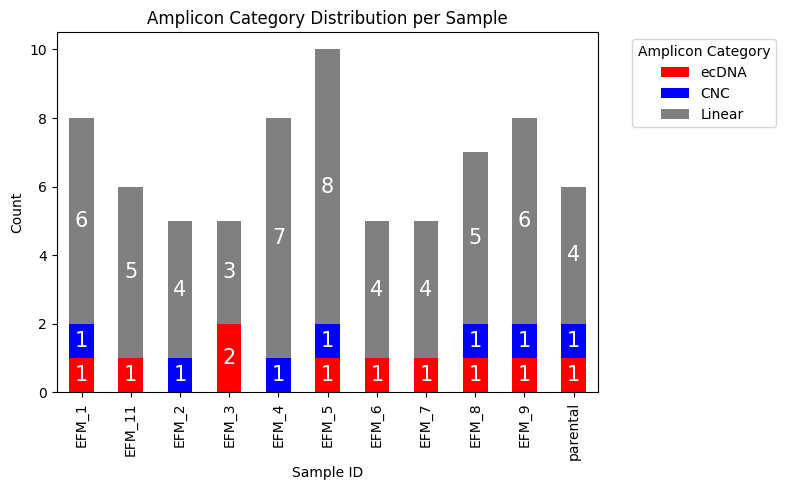

In [230]:
import matplotlib.pyplot as plt

# none 제외
table_no_none = table.drop(columns=["none"], errors="ignore").copy()

# 표시 순서 고정
desired_order = [ "ecDNA", "BFB", "CNC","Linear"]
existing_cols = [c for c in desired_order if c in table_no_none.columns]
table_no_none = table_no_none[existing_cols]

# 원하는 색 지정
color_map = {
    "ecDNA": "red",
    "CNC": "blue",
    "BFB": "green",
    "Linear": "gray"
}
colors = [color_map[col] for col in table_no_none.columns]

# plot
ax = table_no_none.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=colors
)

# 각 bar segment 안에 숫자 넣기
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_y() + height / 2
        ax.text(
            x, y, f"{int(height)}",
            ha="center", va="center",
            fontsize=15, color="white"
        )

plt.ylabel("Count")
plt.xlabel("Sample ID")
plt.title("Amplicon Category Distribution per Sample")
plt.legend(title="Amplicon Category", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [291]:
df[(df['sample_id']=='EFM_3')&(df['amplicon_type']=='ecDNA')]
df[(df['sample_id']=='EFM_1')]

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
61,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon10,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon10,Linear,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,12:46081900-46871919,"ARID2,",790020,706617,5.828209,1,4,0,3,0,0,3,EFM19,EFM_1,Linear
62,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon11,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon11,No amp/Invalid,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.835222,1,1,0,0,0,0,0,EFM19,EFM_1,none
63,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon12,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33368118-33433123,",",65006,65005,4.385335,1,1,0,0,0,0,0,EFM19,EFM_1,none
64,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon13,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon13,No amp/Invalid,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:9386618-10131619,"GAS7,",745002,744999,3.132734,1,3,0,2,0,0,2,EFM19,EFM_1,none
65,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon14,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon14,Linear,None detected,None detected,0,14,amplicon14,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"MAP2K4,SREBF1,COPS3,",7399997,5893349,6.697657,1,10,2,5,1,0,5,EFM19,EFM_1,Linear
66,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon1,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon1,Linear,None detected,None detected,0,1,amplicon1,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,1:46223262-46503266,",",280005,280003,4.272619,1,2,0,1,0,0,1,EFM19,EFM_1,Linear
67,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon2,Linear,None detected,None detected,0,2,amplicon2,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,1:57048384-57818394,",",770011,662393,6.203369,1,3,0,2,1,0,2,EFM19,EFM_1,Linear
68,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon3,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon3,Linear,None detected,None detected,0,3,amplicon3,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,1:120552171-120642163,"NOTCH2,",89993,89992,5.874724,1,1,0,0,0,0,0,EFM19,EFM_1,Linear
69,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon4,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon4,No amp/Invalid,None detected,None detected,0,4,amplicon4,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,5:590025-785031,",",195007,156831,4.347303,1,2,0,1,0,0,1,EFM19,EFM_1,none
70,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K-amplicon5,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,amplicon5,No amp/Invalid,None detected,None detected,0,5,amplicon5,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,5:41805643-42385645,",",580003,580002,2.552125,1,1,0,0,0,0,0,EFM19,EFM_1,none


In [232]:
amplicon_ERBB2 = df[df['OncogenesAmplified'].str.contains(r'\bERBB2\b', na=False)]
print(amplicon_ERBB2.shape)
amplicon_ERBB2.head(2)

(11, 26)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
12,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon8,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon8,Complex-non-cyclic,None detected,None detected,0,8,amplicon8,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,4,"12:31901506-33300002,13:20940908-20999226,17:3...","CD79B,ITGA3,MSI2,C17orf37,CSF3,HLF,ERBB2,BRIP1...",20936824,18682400,9.734101,3,60,14,38,13,1,26,EFM19,EFM_5,CNC
25,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC-amplicon8,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC,amplicon8,Complex-non-cyclic,None detected,None detected,0,8,amplicon8,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,6,"12:59342-270363,12:31901506-33300002,13:209409...","ERBB2,NME1,SMARCE1,UBE2C,TBX2,CSF3,MSI2,AURKA,...",44596600,31352102,8.834054,4,98,19,64,13,0,51,EFM19,EFM_9,CNC


In [250]:
# amplicon_ERBB2.to_csv('../summary/amplicon_ERBB2_EFM192A.csv',index=False)

In [285]:
amplicon_ERBB2[amplicon_ERBB2['sample_id']=='parental']

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
45,ECTRES-EFM19-0001-TPX-A04-WGS-BSX7Q9-amplicon6,ECTRES-EFM19-0001-TPX-A04-WGS-BSX7Q9,amplicon6,Complex-non-cyclic,None detected,None detected,0,6,amplicon6,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,6,"8:70156489-146364022,12:31901506-33300002,17:1...","SRSF6,NOV,MAFA,COX6C,NDRG1,BAALC,MLLT6,TNS4,EI...",124616054,77183748,10.852236,4,194,40,129,31,3,106,EFM19,EFM_4,CNC


In [241]:
all_samples = amplicon_ERBB2['sample_id'].unique().tolist()

# ecDNA를 하나라도 가지고 있는 샘플 리스트 추출
ecDNA_samples = amplicon_ERBB2[amplicon_ERBB2['amplicon_type'] == 'ecDNA']['sample_id'].unique().tolist()

# 그룹 분리 (parental 제외)
ecDNA_clones = [s for s in ecDNA_samples if s != 'parental']
other_clones = [s for s in all_samples if s not in ecDNA_samples and s != 'parental']

# 최종 순서: parental -> ecDNA 클론(알파벳순) -> 나머지 클론(알파벳순)
sample_order = []
if 'parental' in all_samples:
    sample_order.append('parental')

sample_order.extend(sorted(ecDNA_clones))
sample_order.extend(sorted(other_clones))

# sample_id를 정의한 순서대로 Categorical 타입 변환
amplicon_ERBB2['sample_id'] = pd.Categorical(
    amplicon_ERBB2['sample_id'], 
    categories=sample_order, 
    ordered=True
)

<ipython-input-241-1adfd421b1ef>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amplicon_ERBB2['sample_id'] = pd.Categorical(


In [242]:
# 비교하고 싶은 주요 수치형 컬럼들
metrics = [
    'N_Chromosomes', 'N_BreakpointEdges', 'TotalIntervalSize', 
    'AmplifiedIntervalSize', 'AverageAmplifiedCopyCount'
]

# 샘플별 평균 통계량 계산
summary_stats = amplicon_ERBB2.groupby('sample_id')[metrics].agg(['mean', 'std', 'count']).round(2)
print(summary_stats)

# CSV로 저장하여 나중에 Nextflow 리포트 등에 활용 가능
# summary_stats.to_csv("ERBB2_amplicon_stats_summary.csv")

          N_Chromosomes           N_BreakpointEdges             
                   mean std count              mean std count   
sample_id                                                       
parental            6.0 NaN     1             182.0 NaN     1  \
EFM_11              6.0 NaN     1              64.0 NaN     1   
EFM_3               3.0 NaN     1              18.0 NaN     1   
EFM_6               5.0 NaN     1              43.0 NaN     1   
EFM_7               6.0 NaN     1              56.0 NaN     1   
EFM_1               3.0 NaN     1              14.0 NaN     1   
EFM_2               5.0 NaN     1              50.0 NaN     1   
EFM_4               4.0 NaN     1              40.0 NaN     1   
EFM_5               3.0 NaN     1              14.0 NaN     1   
EFM_8               4.0 NaN     1              20.0 NaN     1   
EFM_9               4.0 NaN     1              19.0 NaN     1   

          TotalIntervalSize           AmplifiedIntervalSize             
                

<ipython-input-249-4b0b26dda06a>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=amplicon_ERBB2, x='sample_id', y='AverageAmplifiedCopyCount',
<ipython-input-249-4b0b26dda06a>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=amplicon_ERBB2, x='sample_id', y='N_BreakpointEdges',
<ipython-input-249-4b0b26dda06a>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=amplicon_ERBB2, x='sample_id', y='AmplifiedIntervalSize',
<ipython-input-249-4b0b26dda06a>:34: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

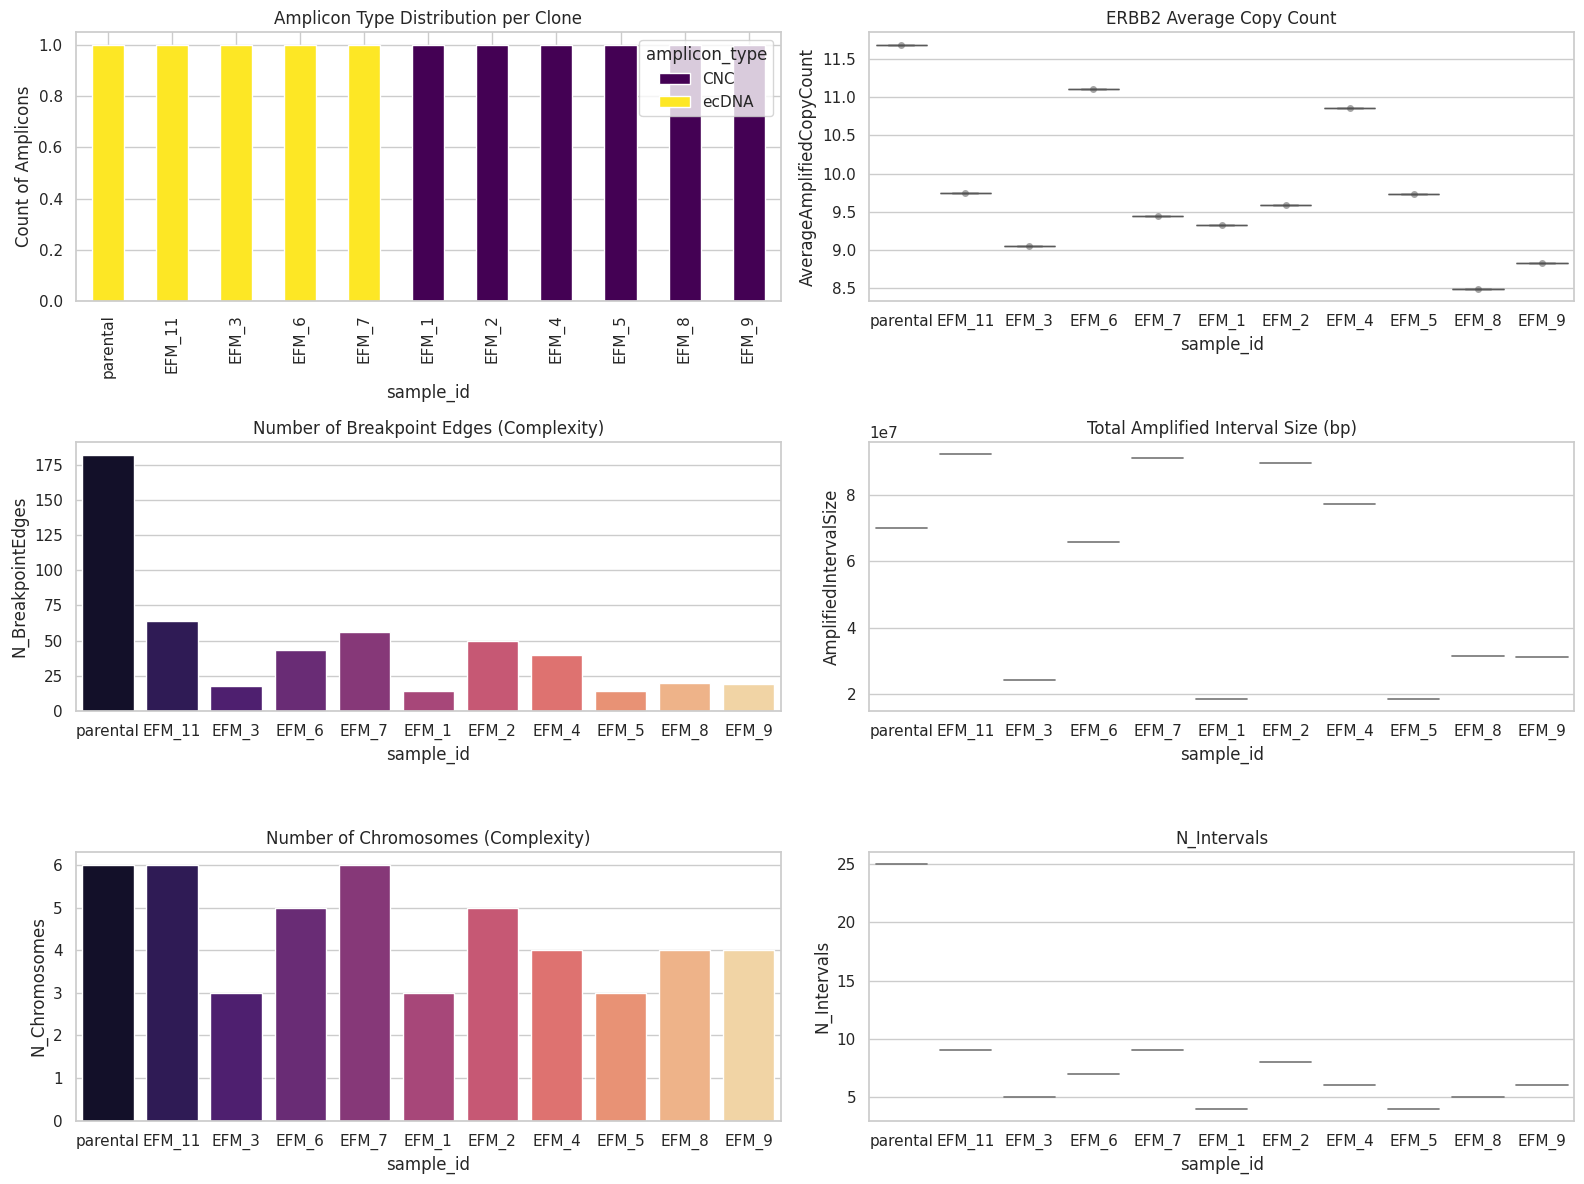

In [249]:
# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# (1) Amplicon Type 분포 (Stacked Bar)
# ecDNA, BFB 등의 구성 변화 확인
type_counts = amplicon_ERBB2.groupby(['sample_id', 'amplicon_type']).size().unstack(fill_value=0)
type_counts.loc[sample_order].plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='viridis')
axes[0, 0].set_title('Amplicon Type Distribution per Clone')
axes[0, 0].set_ylabel('Count of Amplicons')

# (2) Average Amplified Copy Count (Boxplot)
# ERBB2의 증폭 수준이 클론별로 어떻게 변하는지 확인
sns.boxplot(data=amplicon_ERBB2, x='sample_id', y='AverageAmplifiedCopyCount', 
            order=sample_order, ax=axes[0, 1], palette='Set2')
sns.stripplot(data=amplicon_ERBB2, x='sample_id', y='AverageAmplifiedCopyCount', 
              order=sample_order, ax=axes[0, 1], color=".3", alpha=0.5)
axes[0, 1].set_title('ERBB2 Average Copy Count')

# (3) Complexity: Breakpoint Edges
# 구조적 복잡도가 증가했는지 확인 (ecDNA 진화의 척도)
sns.barplot(data=amplicon_ERBB2, x='sample_id', y='N_BreakpointEdges', 
            order=sample_order, ax=axes[1, 0], errorbar='sd', palette='magma')
axes[1, 0].set_title('Number of Breakpoint Edges (Complexity)')

# (4) Amplified Interval Size
# 증폭된 영역의 전체 크기 비교
sns.violinplot(data=amplicon_ERBB2, x='sample_id', y='AmplifiedIntervalSize', 
               order=sample_order, ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Total Amplified Interval Size (bp)')

# (5) N_Chromosomes: 
# 구조적 복잡도가 증가했는지 확인 (ecDNA 진화의 척도)
sns.barplot(data=amplicon_ERBB2, x='sample_id', y='N_Chromosomes', 
            order=sample_order, ax=axes[2, 0], errorbar='sd', palette='magma')
axes[2, 0].set_title('Number of Chromosomes (Complexity)')

# (6) Amplified Interval Size
# 증폭된 영역의 전체 크기 비교
sns.violinplot(data=amplicon_ERBB2, x='sample_id', y='N_Intervals', 
               order=sample_order, ax=axes[2, 1], palette='Pastel1')
axes[2, 1].set_title('N_Intervals')


plt.tight_layout()
# plt.savefig("ERBB2_clonal_comparison_plots.png", dpi=300)
plt.show()

In [ ]:
- ecDNA heterogeneity분석 프레임 짜기
~~~해석할사항: founder 상태 + 증식 과정에서 다시 생긴 ecDNA diversification의 합성 결과
~~~parental bulk 하나가 이미 여러 hidden lineage를 평균
    1) parental
    
A. Stable retention
B. Retention with rewiring
C. Class switch
D. Loss
E. De novo

In [264]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def get_bp_overlap(str1, str2):
    """두 Interval 문자열 간의 겹치는 bp 총합 계산"""
    def parse(s):
        res = []
        for item in s.split(','):
            chrom, pos = item.split(':')
            start, end = map(int, pos.split('-'))
            res.append((chrom, start, end))
        return res

    iv1, iv2 = parse(str1), parse(str2)
    overlap_total = 0
    for c1, s1, e1 in iv1:
        for c2, s2, e2 in iv2:
            if c1 == c2:
                inter_s, inter_e = max(s1, s2), min(e1, e2)
                if inter_s < inter_e:
                    overlap_total += (inter_e - inter_s)
    
    len1 = sum(e-s for _, s, e in iv1)
    len2 = sum(e-s for _, s, e in iv2)
    return overlap_total, len1, len2
import pandas as pd
import numpy as np

# 1. 통계 계산 루프 수정
parental_row = amplicon_ERBB2[amplicon_ERBB2['sample_id'] == 'parental'].iloc[0]
p_intervals = parental_row['Intervals']

comparison_results = []

for _, row in amplicon_ERBB2.iterrows():
    overlap, p_len, c_len = get_bp_overlap(p_intervals, row['Intervals'])
    
    # Jaccard: 전체적인 일치도 (교집합 / 합집합)
    jaccard = overlap / (p_len + c_len - overlap) if (p_len + c_len - overlap) > 0 else 0
    
    # Conservation: Parental의 영역 중 유지된 비율 (Parental 기준)
    conservation = (overlap / p_len) * 100 if p_len > 0 else 0
    
    # Clone_Source_Ratio: 클론의 구성 성분 중 Parental에서 온 비율 (Clone 기준)
    # 이 수치가 높을수록 "이 클론은 Parental의 파편으로 만들어졌다"는 의미입니다.
    clone_source_ratio = (overlap / c_len) * 100 if c_len > 0 else 0
    
    # Novelty: 클론이 새로 획득한 영역의 비율 (Clone 기준)
    novelty = 100 - clone_source_ratio

    comparison_results.append({
        'sample_id': row['sample_id'],
        'amplicon_type': row['amplicon_type'],
        'Jaccard_Similarity': jaccard,
        'Parental_Conservation_%': conservation,
        'Clone_Source_Ratio_%': clone_source_ratio,
        'Novel_Region_%': novelty,
        'Total_Size_bp': c_len,
        'Overlap_bp': overlap
    })

df_sim = pd.DataFrame(comparison_results)

# 정렬: 타입별로 묶고, 클론 소스 비율이 높은 순서대로
df_sim = df_sim.sort_values(by=['amplicon_type','Parental_Conservation_%', 'Clone_Source_Ratio_%'], ascending=[True, True,False])
df_sim

,sample_id,amplicon_type,Jaccard_Similarity,Parental_Conservation_%,Clone_Source_Ratio_%,Novel_Region_%,Total_Size_bp,Overlap_bp
5,EFM_1,CNC,0.139195,14.848011,69.000606,30.999394,20879379,14406898
0,EFM_5,CNC,0.139748,14.907028,69.084808,30.915192,20936820,14464162
9,EFM_8,CNC,0.271267,31.077445,68.090256,31.909744,44285601,30154179
1,EFM_9,CNC,0.270738,31.098058,67.660277,32.339723,44596594,30174179
3,EFM_4,CNC,0.744081,97.456264,75.881863,24.118137,124616048,94560979
7,EFM_2,CNC,0.735479,98.981609,74.108671,25.891329,129594833,96041008
4,EFM_3,ecDNA,0.211245,22.533599,77.158595,22.841405,28336646,21864158
8,EFM_6,ecDNA,0.649367,82.159954,75.595848,24.404152,105454337,79719100
6,EFM_11,ecDNA,0.729757,98.362166,73.873306,26.126694,129194120,95439968
2,EFM_7,ecDNA,0.735936,98.982577,74.154584,25.845416,129515860,96041947


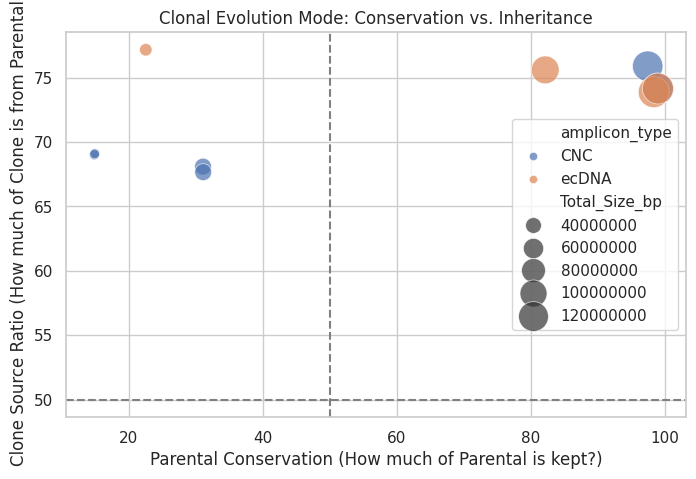

In [267]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_sim[df_sim['sample_id'] != 'parental'], 
    x='Parental_Conservation_%', 
    y='Clone_Source_Ratio_%', 
    hue='amplicon_type', 
    size='Total_Size_bp',
    sizes=(50, 500),
    alpha=0.7
)

plt.axvline(50, color='grey', linestyle='--')
plt.axhline(50, color='grey', linestyle='--')
plt.title('Clonal Evolution Mode: Conservation vs. Inheritance')
plt.xlabel('Parental Conservation (How much of Parental is kept?)')
plt.ylabel('Clone Source Ratio (How much of Clone is from Parental?)')
plt.show()

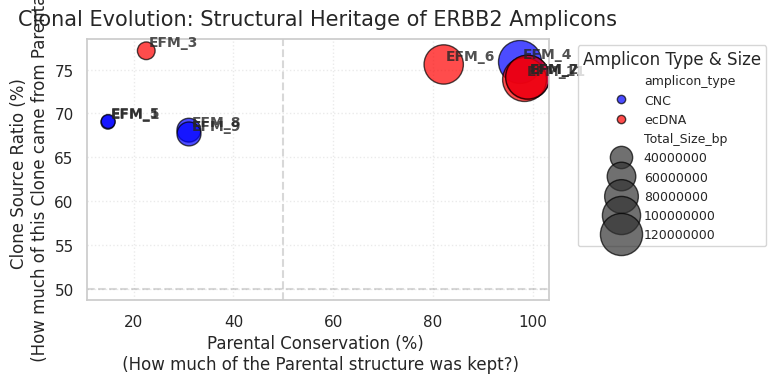

In [278]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 색상 팔레트 정의 (요청하신 색상 기준)
# ecDNA: Red, CNC: Blue, BFB: Green, 나머지는 Grey 계열
color_map = {
    'ecDNA': '#FF0000',   # Red
    'CNC': '#0000FF',     # Blue
    'BFB': '#008000',     # Green
    'Linear': '#808080',  # Grey (기타 타입 대비)
    'Complex non-cyclic': '#0000FF' # CNC의 풀네임 대비
}

plt.figure(figsize=(8, 4))

# 2. 'parental'을 제외한 클론들만 필터링
plot_df = df_sim[df_sim['sample_id'] != 'parental'].copy()

# 3. Scatter Plot 그리기
scatter = sns.scatterplot(
    data=plot_df, 
    x='Parental_Conservation_%', 
    y='Clone_Source_Ratio_%', 
    hue='amplicon_type', 
    palette=color_map, # 지정한 색상 적용
    size='Total_Size_bp',
    sizes=(100, 1000),
    alpha=0.7,
    edgecolor='black', # 점의 테두리를 그려서 가독성 높임
    linewidth=1
)

# 4. 각 점에 sample_id 라벨 추가 (plt.text 루프)
for i in range(plot_df.shape[0]):
    row = plot_df.iloc[i]
    plt.text(
        x=row['Parental_Conservation_%'] + 0.5, # 라벨이 점에 겹치지 않게 약간 오른쪽으로
        y=row['Clone_Source_Ratio_%'] + 0.5, 
        s=row['sample_id'], 
        fontsize=10, 
        fontweight='bold',
        alpha=0.8
    )

# 5. 가이드라인 및 서식 설정
plt.axvline(50, color='grey', linestyle='--', alpha=0.3)
plt.axhline(50, color='grey', linestyle='--', alpha=0.3)

plt.title('Clonal Evolution: Structural Heritage of ERBB2 Amplicons', fontsize=15, pad=10)
plt.xlabel('Parental Conservation (%) \n (How much of the Parental structure was kept?)', fontsize=12)
plt.ylabel('Clone Source Ratio (%) \n (How much of this Clone came from Parental?)', fontsize=12)

# 범례 설정 (그래프 바깥쪽으로 배치)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Amplicon Type & Size',fontsize=9)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [279]:
# A. structural heterogeneity
# 어떤 interval과 breakpoint가 남았는가

# B. topological heterogeneity
# round인가, non-circular/CNC인가, linear인가

# C. dosage heterogeneity
# copy number가 얼마인가

ModuleNotFoundError: No module named 'adjust_text'

In [281]:
# intact inheritance

# fission into multiple ecDNAs

# selective streamlining

# class switch to CNC/linear

# loss

ERROR: Could not find a version that satisfies the requirement adjust_text
ERROR: No matching distribution found for adjust_text


In [119]:
# OncogenesAmplified 컬럼의 쉼표로 구분된 유전자들을 explode
# 1. 먼저 쉼표(,)로 split → 리스트로 변환
df['OncogenesAmplified_split'] = df['OncogenesAmplified'].str.split(',')

# 2. explode를 통해 유전자별로 row 늘리기
df_exploded = df.explode('OncogenesAmplified_split')

# 3. 양끝 공백 제거 및 빈 문자열 제거
df_exploded['OncogenesAmplified_split'] = df_exploded['OncogenesAmplified_split'].str.strip()
df_exploded = df_exploded[df_exploded['OncogenesAmplified_split'] != '']

# 4. 컬럼명 정리
df_exploded = df_exploded.rename(columns={'OncogenesAmplified_split': 'Oncogene'})

# 결과 확인
print(df.shape,df_exploded.shape)
df_exploded.head()

(129, 27) (846, 27)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type,Oncogene
2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon12,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:9386618-10131619,"GAS7,",745002,745001,3.458185,1,1,0,0,0,0,0,EFM19,EFM_5,none,GAS7
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,Linear,SREBF1
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,Linear,COPS3
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,Linear,MAP2K4
4,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,Linear,None detected,None detected,0,14,amplicon14,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,20:39676747-63025520,"AURKA,SALL4,SDC4,RAB22A,SS18L1,ZNF217,EEF1A2,S...",23348774,12794676,7.026961,1,32,4,23,0,0,23,EFM19,EFM_5,Linear,AURKA


## AA gene list

In [120]:
sample_mapping.head(2)

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id,aa_barcode
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949


In [123]:
df_exploded['amplicon_type'].unique()

array(['none', 'Linear', 'ecDNA', 'Complex-non-cyclic'], dtype=object)

In [128]:
sample_order = (
    df_exploded["sample_id"]
    .unique()
)

sample_order = sorted(
    sample_order,
    key=lambda x: (x != "parental", x)
)

cn_matrix = df_exploded.pivot(
    index="Oncogene",
    columns="sample_id",
    values="AverageAmplifiedCopyCount"
).reindex(columns=sample_order)

cat_matrix = df_exploded.pivot(
    index="Oncogene",
    columns="sample_id",
    values="amplicon_type"
).reindex(columns=sample_order)

color_map = {
    "ecDNA": "red",                 # red
    "BFB": "green",                   # orange
    "Linear": "gray",  # blue
    "Complex-non-cyclic": "blue",    # green
    "none": "white"                # gray
}

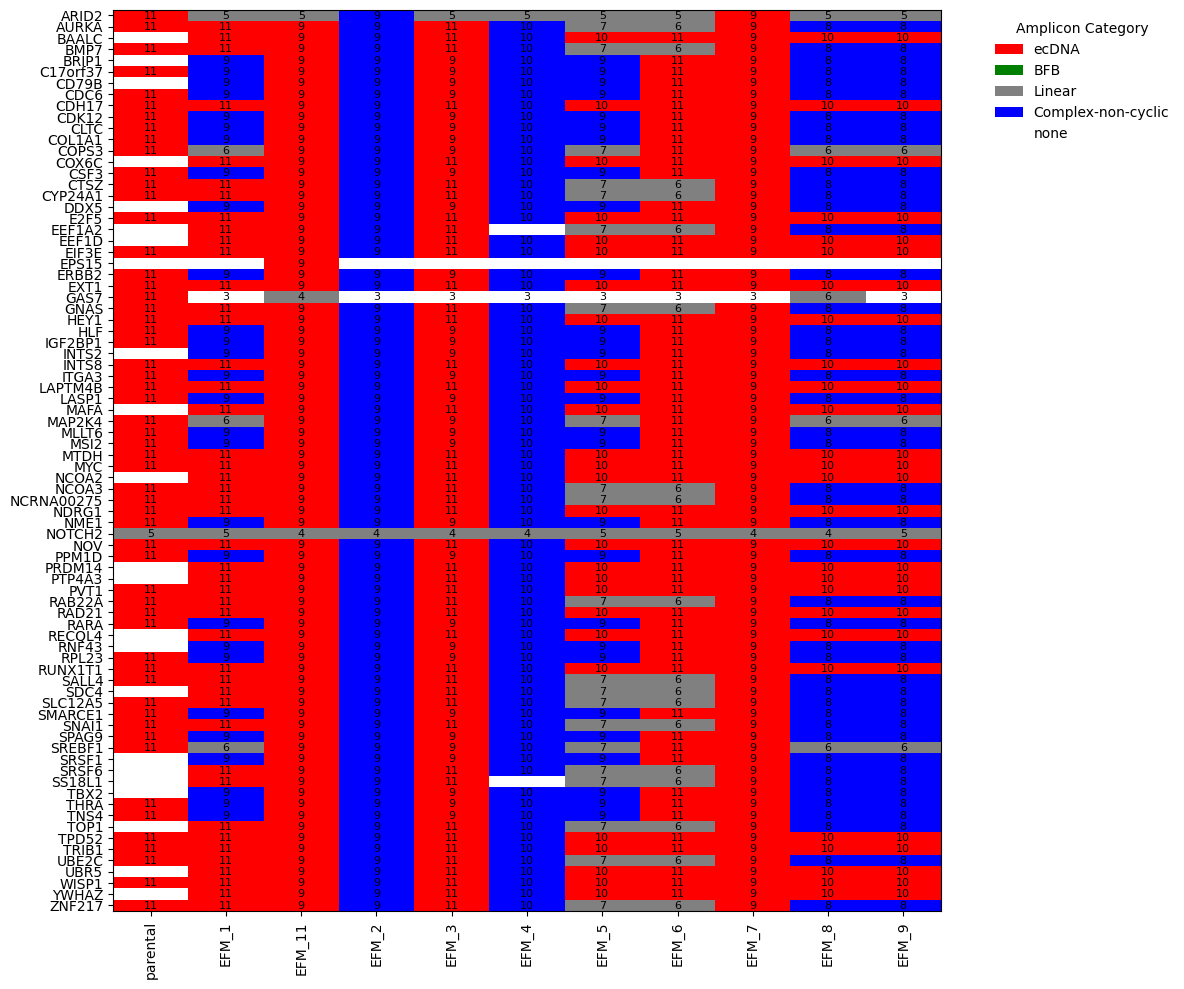

In [129]:
fig, ax = plt.subplots(figsize=(12, 10))

n_genes = cn_matrix.shape[0]
n_samples = cn_matrix.shape[1]

for i in range(n_genes):
    for j in range(n_samples):
        
        category = cat_matrix.iloc[i, j]
        value = cn_matrix.iloc[i, j]
        
        color = color_map.get(category, "white")
        
        # 사각형 그리기
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax.add_patch(rect)
        
        # CN 숫자 annotation
        if not pd.isna(value):
            ax.text(
                j + 0.5,
                i + 0.5,
                int(value),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

ax.set_xlim(0, n_samples)
ax.set_ylim(0, n_genes)

ax.set_xticks(np.arange(n_samples) + 0.5)
ax.set_xticklabels(cn_matrix.columns, rotation=90)

ax.set_yticks(np.arange(n_genes) + 0.5)
ax.set_yticklabels(cn_matrix.index)

legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in color_map.items()
]

ax.legend(
    handles=legend_elements,
    title="Amplicon Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)


ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [126]:
# cn_raw

### Clustering

In [142]:
df_onehot.head(2)

,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,Oncogene,amplicon_type_Complex-non-cyclic,amplicon_type_Linear,amplicon_type_ecDNA,amplicon_type_none
2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon12,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon12,No amp/Invalid,None detected,None detected,0,12,amplicon12,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:9386618-10131619,"GAS7,",745002,745001,3.458185,1,1,0,0,0,0,0,EFM19,EFM_5,GAS7,False,False,False,True
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon13,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon13,Linear,None detected,None detected,0,13,amplicon13,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,17:11616616-19016612,"SREBF1,COPS3,MAP2K4,",7399997,5845391,7.183853,1,7,0,6,1,0,6,EFM19,EFM_5,SREBF1,False,True,False,False


In [143]:
df_onehot = pd.get_dummies(
    df_exploded,
    columns=["amplicon_type"]
)

# print(df_onehot.head())

feature_matrix = pd.pivot_table(
    df_onehot,
    index="Oncogene",
    columns="sample_id",
    values=["AverageAmplifiedCopyCount",
            "amplicon_type_ecDNA",
            "amplicon_type_BFB",
            "amplicon_type_Linear",
            "amplicon_type_Complex-non-cyclic",
            "amplicon_type_none"],
    aggfunc="max"
)

feature_matrix = pd.pivot_table(
    df_onehot,
    index="Oncogene",
    columns="sample_id",
    values=["AverageAmplifiedCopyCount",
            "amplicon_type_ecDNA",
            "amplicon_type_BFB",
            "amplicon_type_Linear",
            "amplicon_type_Complex-non-cyclic",
            "amplicon_type_none"],
    aggfunc="max"
)

# feature_matrix.head()

KeyError: 'amplicon_type_BFB'

In [144]:
feature_matrix.columns = [
    f"{feature}_{sample}"
    for feature, sample in feature_matrix.columns
]

ValueError: too many values to unpack (expected 2)

In [145]:
clone_feature = feature_matrix.T
# clone_feature.head()

In [146]:
# CN magnitude와 type을 곱해 하나의 구조-가중 CN으로 만들 수도 있습니다.
df_exploded["weighted_cn"] = (
    df_exploded["AverageAmplifiedCopyCount"] *
    df_exploded["amplicon_type"].map({
        "ecDNA": 5,
        "BFB": 3,
        "Linear amplification": 1,
        "Complex non-cyclic": 2,
        "none": 0
    })
)

cn_weighted = pd.pivot_table(
    df_exploded,
    index="sample_id",
    columns="Oncogene",
    values="weighted_cn",
    aggfunc="max"
).fillna(0)

In [147]:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

distance_matrix = pdist(cn_weighted, metric="euclidean")
# distance_matrix = pdist(cn_weighted, metric="correlation")

Z = linkage(distance_matrix, method="average")
# Z

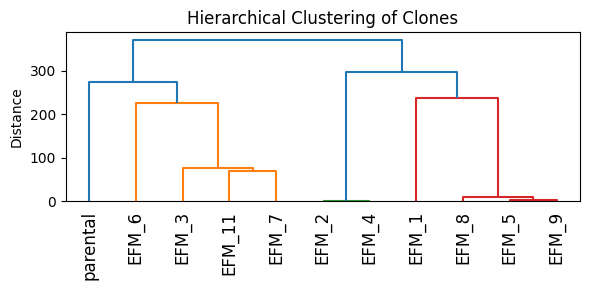

In [148]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(6, 3))

dendrogram(
    Z,
    labels=cn_weighted.index,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Clones")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

(10, 79)


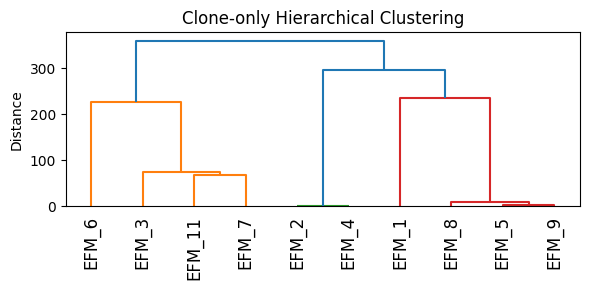

In [149]:
### cluster within clones (elminate parental)
cn_clone = cn_weighted.drop(index="parental", errors="ignore")
print(cn_clone.shape)
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist

distance_matrix = pdist(cn_clone, metric="euclidean")
Z_clone = linkage(distance_matrix, method="average")


plt.figure(figsize=(6, 3))
dendrogram(
    Z_clone,
    labels=cn_clone.index,
    leaf_rotation=90
)
plt.title("Clone-only Hierarchical Clustering")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [150]:
from scipy.cluster.hierarchy import fcluster

# cluster_labels = fcluster(Z_clone, t=5, criterion="maxclust")
cluster_labels = fcluster(Z_clone, t=1000, criterion="distance")
cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [151]:
ddata = dendrogram(
    Z_clone,
    labels=cn_clone.index
)

leaf_order = ddata["ivl"]
print(leaf_order)

['EFM_6', 'EFM_3', 'EFM_11', 'EFM_7', 'EFM_2', 'EFM_4', 'EFM_1', 'EFM_8', 'EFM_5', 'EFM_9']


In [163]:
## manually grouping 
cluster_map = {}

for s in leaf_order[0:4]:
    cluster_map[s] = 3
for s in leaf_order[4:6]:
    cluster_map[s] = 2
for s in leaf_order[6:]:
    cluster_map[s] = 1

    
cluster_df = pd.DataFrame({
    "sample_id": list(cluster_map.keys()),
    "cluster_group": list(cluster_map.values())
})
# 
cluster_df

,sample_id,cluster_group
0,EFM_6,3
1,EFM_3,3
2,EFM_11,3
3,EFM_7,3
4,EFM_2,2
5,EFM_4,2
6,EFM_1,1
7,EFM_8,1
8,EFM_5,1
9,EFM_9,1


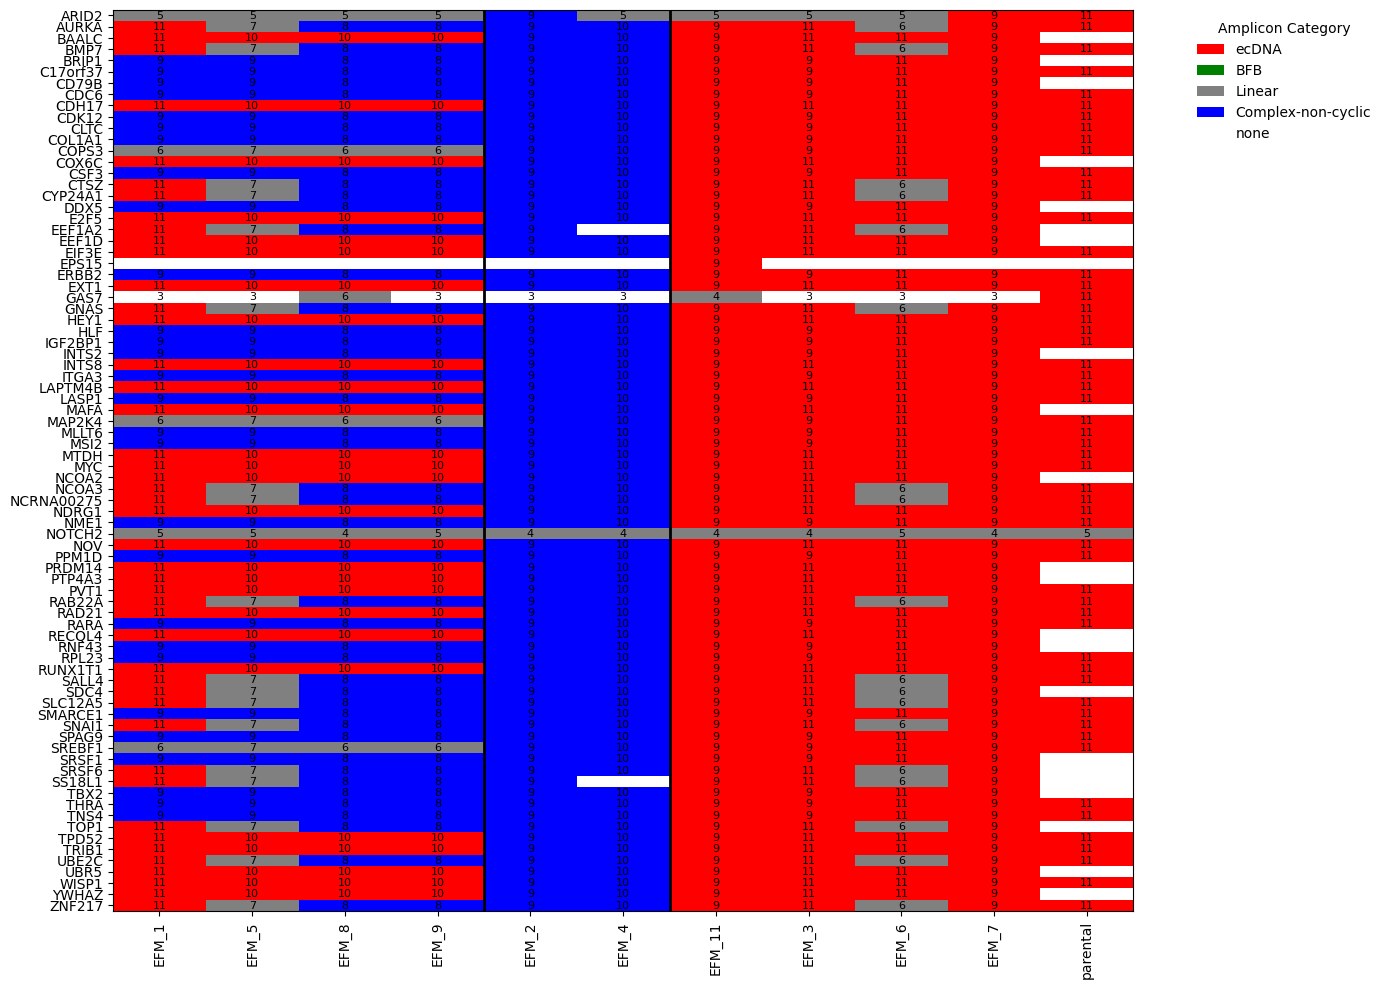

In [164]:
# =========================
# 1️⃣ Sample order by cluster
# =========================

ordered_samples = (
    cluster_df
    .sort_values(["cluster_group", "sample_id"])
    ["sample_id"]
    .tolist()
)

# parental이 matrix에 존재하면 추가
if "parental" in cn_matrix.columns:
    ordered_samples = ordered_samples + ["parental"]
else:
    ordered_samples = ordered_samples
    
# matrix reorder
cn_matrix = cn_matrix[ordered_samples]
cat_matrix = cat_matrix[ordered_samples]

# =========================
# 2️⃣ Cluster boundary 계산
# =========================

cluster_sizes = (
    cluster_df
    .sort_values(["cluster_group", "sample_id"])
    .groupby("cluster_group")
    .size()
)

boundaries = np.cumsum(cluster_sizes.values)

# =========================
# 3️⃣ Heatmap 그리기
# =========================

fig, ax = plt.subplots(figsize=(14, 10))

n_genes = cn_matrix.shape[0]
n_samples = cn_matrix.shape[1]

for i in range(n_genes):
    for j in range(n_samples):
        
        category = cat_matrix.iloc[i, j]
        value = cn_matrix.iloc[i, j]
        
        color = color_map.get(category, "white")
        
        # cell rectangle
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax.add_patch(rect)
        
        # CN annotation
        if not pd.isna(value):
            ax.text(
                j + 0.5,
                i + 0.5,
                int(value),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

# axis 설정
ax.set_xlim(0, n_samples)
ax.set_ylim(0, n_genes)

ax.set_xticks(np.arange(n_samples) + 0.5)
ax.set_xticklabels(cn_matrix.columns, rotation=90)

ax.set_yticks(np.arange(n_genes) + 0.5)
ax.set_yticklabels(cn_matrix.index)

# cluster 경계선
for b in boundaries[:-1]:
    ax.axvline(b, color="black", linewidth=2)

# legend
legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in color_map.items()
]

ax.legend(
    handles=legend_elements,
    title="Amplicon Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [154]:
cn_matrix.columns


Index(['EFM_11', 'EFM_3', 'EFM_6', 'EFM_7', 'EFM_2', 'EFM_4', 'EFM_1', 'EFM_5',
       'EFM_8', 'EFM_9', 'parental'],
      dtype='object', name='sample_id')

In [155]:
# ecDNA는:uneven segregation/dynamic copy number change/structural instability
# => single-cell 유래 clone도 내부적으로 구조가 계속 변함
# clone ≠ genetically uniform population

# ✔ Oncogene CN
# ✔ Amplicon type
# ✔ PURPLE segment CN
# ✔ Amplicon complexity score
# ✔ ERBB2 locus SV or mutation

# "resistance mechanism이 다를 가능성이 높은 clone"을 분리???


# SV_summary

In [299]:
# ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_SV_summary_20260320.csv

aa_SV=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_SV_summary_20260320.csv')
# (1618, 15)
print(aa_SV.shape)
aa_SV.head()

aa_SV=pd.merge(aa_SV, aaSuite_gemline_ms[['aa_barcode','amplicon_number','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_number'])
print(aa_SV.shape) #(1618, 18)


aa_SV_sub = aa_SV[(aa_SV['source_barcode']=='EFM19')]

print(aa_SV_sub.shape) #(690, 18)

aa_SV_sub.head(2)




(1618, 15)
(1618, 18)
(690, 18)


,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN,EFM19,EFM_5,Linear
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN,EFM19,EFM_5,Linear


In [302]:
# amplicon_type별 sv_type 빈도 계산
sv_summary = aa_SV_sub.groupby(['amplicon_type', 'sv_type']).size().unstack(fill_value=0)
sv_summary

sv_type,duplication-like,foldback,interchromosomal,inversion
amplicon_type,,,,
CNC,44,10,32,73
Linear,3,4,4,10
ecDNA,142,68,73,226
none,0,1,0,0


In [303]:
df=aa_SV_sub.copy()
# 1. 데이터 분리
parental_sv = df[df['sample_id'] == 'parental'].copy()
test_sv = df[df['sample_id'] != 'parental'].copy()

def classify_origin(row, ref_df, threshold=10):
    # 같은 염색체와 타입을 가진 parental 데이터만 필터링
    match = ref_df[
        (ref_df['chrom1'] == row['chrom1']) & 
        (ref_df['chrom2'] == row['chrom2']) &
        (ref_df['sv_type'] == row['sv_type'])
    ]
    
    if match.empty:
        return "De-novo (New Site)"

    # 좌표 차이 계산 (pos1, pos2 둘 다 threshold 이내여야 함)
    dist1 = (match['pos1'] - row['pos1']).abs()
    dist2 = (match['pos2'] - row['pos2']).abs()
    
    # 두 위치 모두 threshold 이내인 것이 하나라도 있는지 확인
    is_match = ((dist1 <= threshold) & (dist2 <= threshold)).any()
    
    if is_match:
        return "Parental-derived"
    else:
        # 하나만 맞거나 둘 다 범위를 벗어난 경우
        return "De-novo (Rearranged)"

# 2. 결과 적용
test_sv['origin_label'] = test_sv.apply(lambda x: classify_origin(x, parental_sv), axis=1)

# 3. 확인 (예시)
print(test_sv[['sample_id', 'sv_type', 'pos1', 'pos2', 'origin_label']].head())

  sample_id           sv_type      pos1       pos2          origin_label
0     EFM_5          foldback  45643848   45646230  De-novo (Rearranged)
1     EFM_5         inversion  46843243   47214580  De-novo (Rearranged)
2     EFM_5  duplication-like  47244379   56230751      Parental-derived
3     EFM_5         inversion  47965687   54748124      Parental-derived
4     EFM_5  interchromosomal  57151411  117296688  De-novo (Rearranged)


In [305]:

def calculate_sv_precision(row, ref_df):
    # 1. 염색체 쌍과 SV 타입이 같은 Parental 후보군 필터링
    match = ref_df[
        (ref_df['chrom1'] == row['chrom1']) & 
        (ref_df['chrom2'] == row['chrom2']) &
        (ref_df['sv_type'] == row['sv_type'])
    ]
    
    if match.empty:
        return pd.Series([np.nan, np.nan, np.nan, "De-novo"])

    # 2. 모든 후보와의 거리 계산 (pos1, pos2 각각)
    # 각 row마다 가장 가까운(최소 거리) Parental SV를 찾습니다.
    diffs = pd.DataFrame({
        'd1': (match['pos1'] - row['pos1']).abs(),
        'd2': (match['pos2'] - row['pos2']).abs()
    })
    diffs['total_d'] = diffs['d1'] + diffs['d2']
    
    # 가장 '가까운' 세트를 선택
    best_match = diffs.loc[diffs['total_d'].idxmin()]
    d1, d2 = best_match['d1'], best_match['d2']
    max_d = max(d1, d2)

    # 3. 디테일한 카테고리 분류 (기준은 박사님 연구 목적에 따라 조정 가능)
    if max_d == 0:
        grade = "Exact Match (0bp)"
    elif max_d <= 10:
        grade = f"Near Match (≤10bp)"
    elif max_d <= 50:
        grade = f"Similar (≤50bp)"
    elif max_d <= 500:
        grade = "Distal (≤500bp)" # 구조는 비슷하나 Breakpoint가 이동함
    else:
        grade = "De-novo (Position Shift)"

    return pd.Series([d1, d2, max_d, grade])

# 실제 적용
# 결과 컬럼들을 한 번에 추가합니다.
test_sv[['dist_pos1', 'dist_pos2', 'max_dist', 'similarity_grade']] = test_sv.apply(
    lambda x: calculate_sv_precision(x, parental_sv), axis=1
)

In [306]:
test_sv

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,origin_label,dist_pos1,dist_pos2,max_dist,similarity_grade
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN,EFM19,EFM_5,Linear,De-novo (Rearranged),0.0,15.0,15.0,Similar (≤50bp)
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN,EFM19,EFM_5,Linear,De-novo (Rearranged),58.0,36.0,58.0,Distal (≤500bp)
2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,47244379,20,56230751,duplication-like,2,Linear,-+,47244380,56230750,0.0,NaN,EFM19,EFM_5,Linear,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
3,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon14,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,47965687,20,54748124,inversion,2,NaN,--,47965688,54748125,0.0,NaN,EFM19,EFM_5,Linear,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
4,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon2,1,57151411,8,117296688,interchromosomal,2,NaN,-+,57151412,117296687,NaN,NaN,EFM19,EFM_5,ecDNA,De-novo (Rearranged),0.0,85.0,85.0,Distal (≤500bp)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon8,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon8,17,56911939,17,58789577,inversion,3,NaN,++,56911938,58789576,1.0,T,EFM19,EFM_8,CNC,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
976,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon8,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon8,20,45245127,20,45576860,inversion,2,NaN,--,45245128,45576861,1.0,A,EFM19,EFM_8,CNC,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
977,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon8,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon8,20,46843269,20,47214619,inversion,3,Complex-non-cyclic,--,46843270,47214620,NaN,NaN,EFM19,EFM_8,CNC,De-novo (Rearranged),84.0,75.0,84.0,Distal (≤500bp)
978,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon8,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,amplicon8,20,49537594,20,53130898,duplication-like,2,Complex-non-cyclic,-+,49537595,53130897,2.0,CA,EFM19,EFM_8,CNC,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)


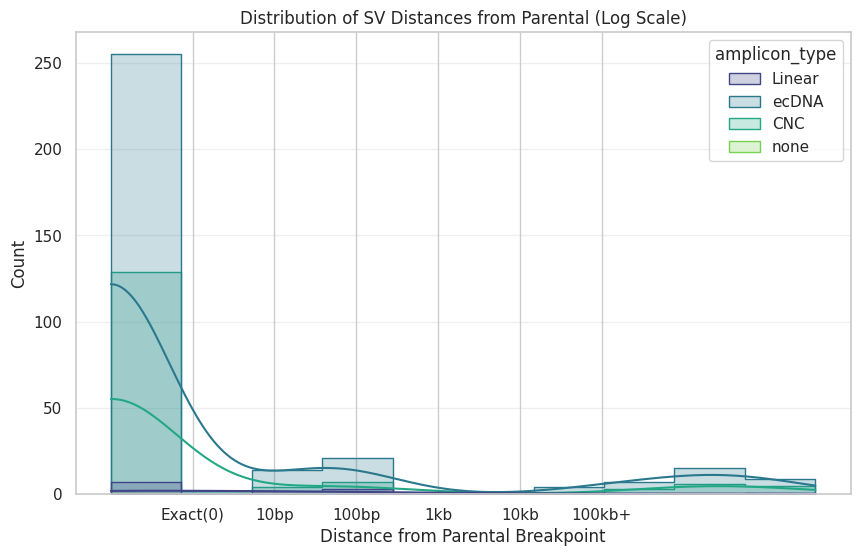

In [309]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 0bp인 데이터도 로그를 취하기 위해 아주 작은 값을 더해줍니다 (0 -> 0.1)
plot_df = test_sv.copy()
plot_df['max_dist_log'] = np.log10(plot_df['max_dist'] + 0.1)

plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x='max_dist_log', hue='amplicon_type', 
             element="step", kde=True, palette='viridis')

# X축 라벨을 실제 bp 단위로 표시
ticks = [0, 1, 2, 3, 4, 5] # 0.1bp, 10bp, 100bp, 1kb, 10kb, 100kb
plt.xticks(ticks, ['Exact(0)', '10bp', '100bp', '1kb', '10kb', '100kb+'])

plt.title('Distribution of SV Distances from Parental (Log Scale)')
plt.xlabel('Distance from Parental Breakpoint')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()
# plt.savefig('sv_distance_distribution.png')

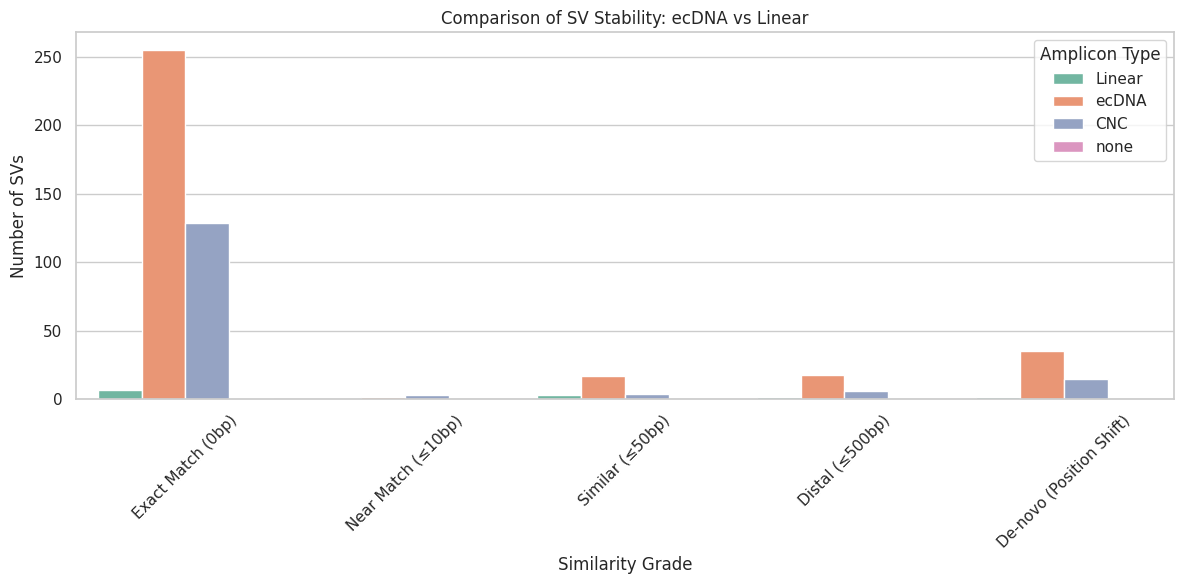

In [310]:
# 순서 고정
order = ["Exact Match (0bp)", "Near Match (≤10bp)", "Similar (≤50bp)", "Distal (≤500bp)", "De-novo (Position Shift)"]

plt.figure(figsize=(12, 6))
# 비율(Percentage)로 시각화
sns.countplot(data=test_sv, x='similarity_grade', hue='amplicon_type', 
              order=order, palette='Set2')

plt.xticks(rotation=45)
plt.title('Comparison of SV Stability: ecDNA vs Linear')
plt.xlabel('Similarity Grade')
plt.ylabel('Number of SVs')
plt.legend(title='Amplicon Type')
plt.tight_layout()
plt.show()

# plt.savefig('sv_similarity_comparison.png')

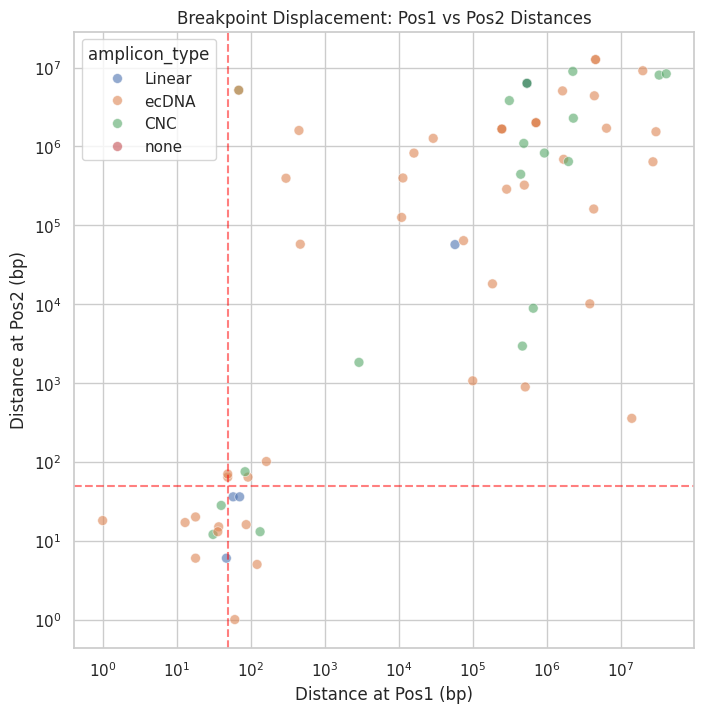

In [311]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=test_sv, x='dist_pos1', y='dist_pos2', 
                hue='amplicon_type', alpha=0.6, s=50)

# 50bp 가이드라인 추가
plt.axhline(50, color='red', linestyle='--', alpha=0.5)
plt.axvline(50, color='red', linestyle='--', alpha=0.5)

plt.xscale('log')
plt.yscale('log')
plt.title('Breakpoint Displacement: Pos1 vs Pos2 Distances')
plt.xlabel('Distance at Pos1 (bp)')
plt.ylabel('Distance at Pos2 (bp)')
plt.show()

# plt.savefig('sv_scatter_dist.png')

In [313]:
test_sv.head()

test_sv[(test_sv['sample_id']=='EFM_11')&(test_sv['amplicon_number']=='amplicon2')]

,amplicon_barcode,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id,amplicon_type,origin_label,dist_pos1,dist_pos2,max_dist,similarity_grade
291,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,1,51789309,8,117394555,interchromosomal,2,NaN,-+,51789310,117394554,NaN,NaN,EFM19,EFM_11,ecDNA,De-novo (Rearranged),468.0,57492.0,57492.0,De-novo (Position Shift)
292,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,1,51789314,8,85001030,interchromosomal,2,NaN,--,51789315,85001031,NaN,NaN,EFM19,EFM_11,ecDNA,De-novo (Rearranged),300.0,394708.0,394708.0,De-novo (Position Shift)
293,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,1,51789614,8,85395738,interchromosomal,3,NaN,+-,51789613,85395739,-4.0,TTGT,EFM19,EFM_11,ecDNA,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
294,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,1,57155196,8,130195209,interchromosomal,4,unknown,-+,57155197,130195208,NaN,NaN,EFM19,EFM_11,ecDNA,De-novo (Rearranged),17.0,0.0,17.0,Similar (≤50bp)
295,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,8,81088002,8,84890545,inversion,2,unknown,--,81088003,84890546,2.0,CA,EFM19,EFM_11,ecDNA,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,17,56911939,17,58789577,inversion,2,unknown,++,56911938,58789576,1.0,T,EFM19,EFM_11,ecDNA,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
351,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,20,45243466,20,48079425,inversion,4,NaN,++,45243465,48079424,NaN,NaN,EFM19,EFM_11,ecDNA,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)
352,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,20,45643747,20,45645124,foldback,4,unknown,--,45643748,45645125,-15.0,AGACTGGGCTCAAGT,EFM19,EFM_11,ecDNA,De-novo (Rearranged),92.0,64.0,92.0,Distal (≤500bp)
353,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,amplicon2,20,49537594,20,53130898,duplication-like,4,NaN,-+,49537595,53130897,2.0,CA,EFM19,EFM_11,ecDNA,Parental-derived,0.0,0.0,0.0,Exact Match (0bp)


In [325]:
amplicon_ERBB2['amp_barcode'] = amplicon_ERBB2['aa_barcode']+'_'+amplicon_ERBB2['amplicon_number']
amp_barcode_ERBB2 = amplicon_ERBB2['amp_barcode'].unique().tolist()
len(amp_barcode_ERBB2)
# amplicon_ERBB2.head(2)

<ipython-input-325-ac1dfe41410b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amplicon_ERBB2['amp_barcode'] = amplicon_ERBB2['aa_barcode']+'_'+amplicon_ERBB2['amplicon_number']


11

In [326]:
amp_barcode_ERBB2

['ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon8',
 'ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC_amplicon8',
 'ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2',
 'ECTRES-EFM19-0001-TPX-A04-WGS-BSX7Q9_amplicon6',
 'ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8',
 'ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K_amplicon9',
 'ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2',
 'ECTRES-EFM19-0001-TPX-A02-WGS-KVS1LG_amplicon2',
 'ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2',
 'ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon8',
 'ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2']

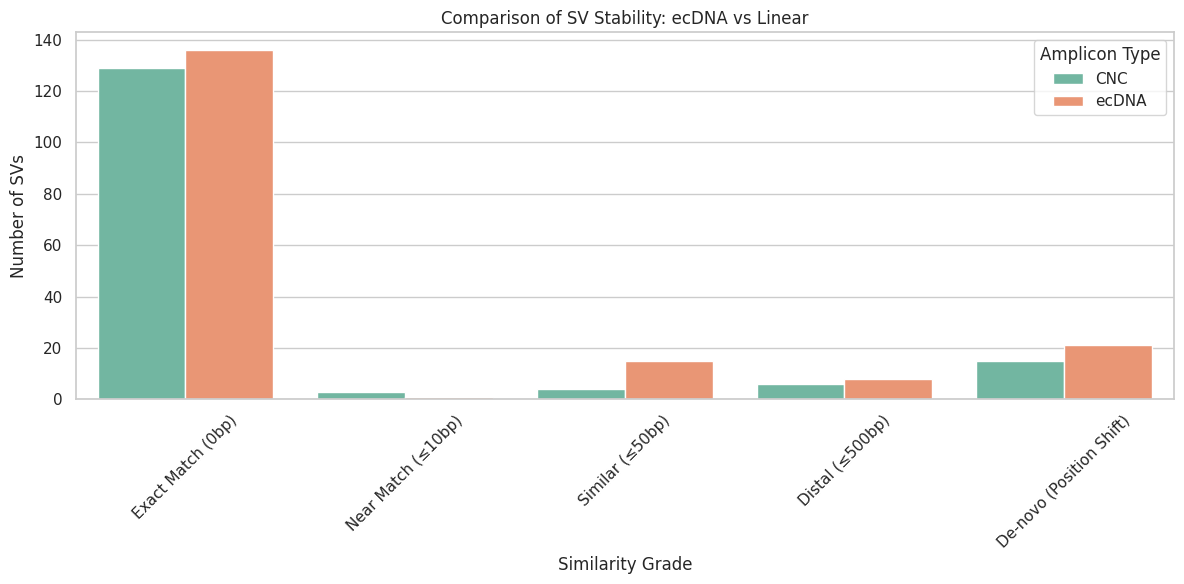

In [327]:
plot_df = test_sv[(test_sv['amplicon_barcode'].isin(amp_barcode_ERBB2))]

order = ["Exact Match (0bp)", "Near Match (≤10bp)", "Similar (≤50bp)", "Distal (≤500bp)", "De-novo (Position Shift)"]

plt.figure(figsize=(12, 6))
# 비율(Percentage)로 시각화
sns.countplot(data=plot_df, x='similarity_grade', hue='amplicon_type', 
              order=order, palette='Set2')

plt.xticks(rotation=45)
plt.title('Comparison of SV Stability: ecDNA vs Linear')
plt.xlabel('Similarity Grade')
plt.ylabel('Number of SVs')
plt.legend(title='Amplicon Type')
plt.tight_layout()
plt.show()

# plt.savefig('sv_similarity_comparison.png')

<ipython-input-333-b8eada44d143>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['sample_amp']=plot_df['sample_id']+'_'+plot_df['amplicon_number']


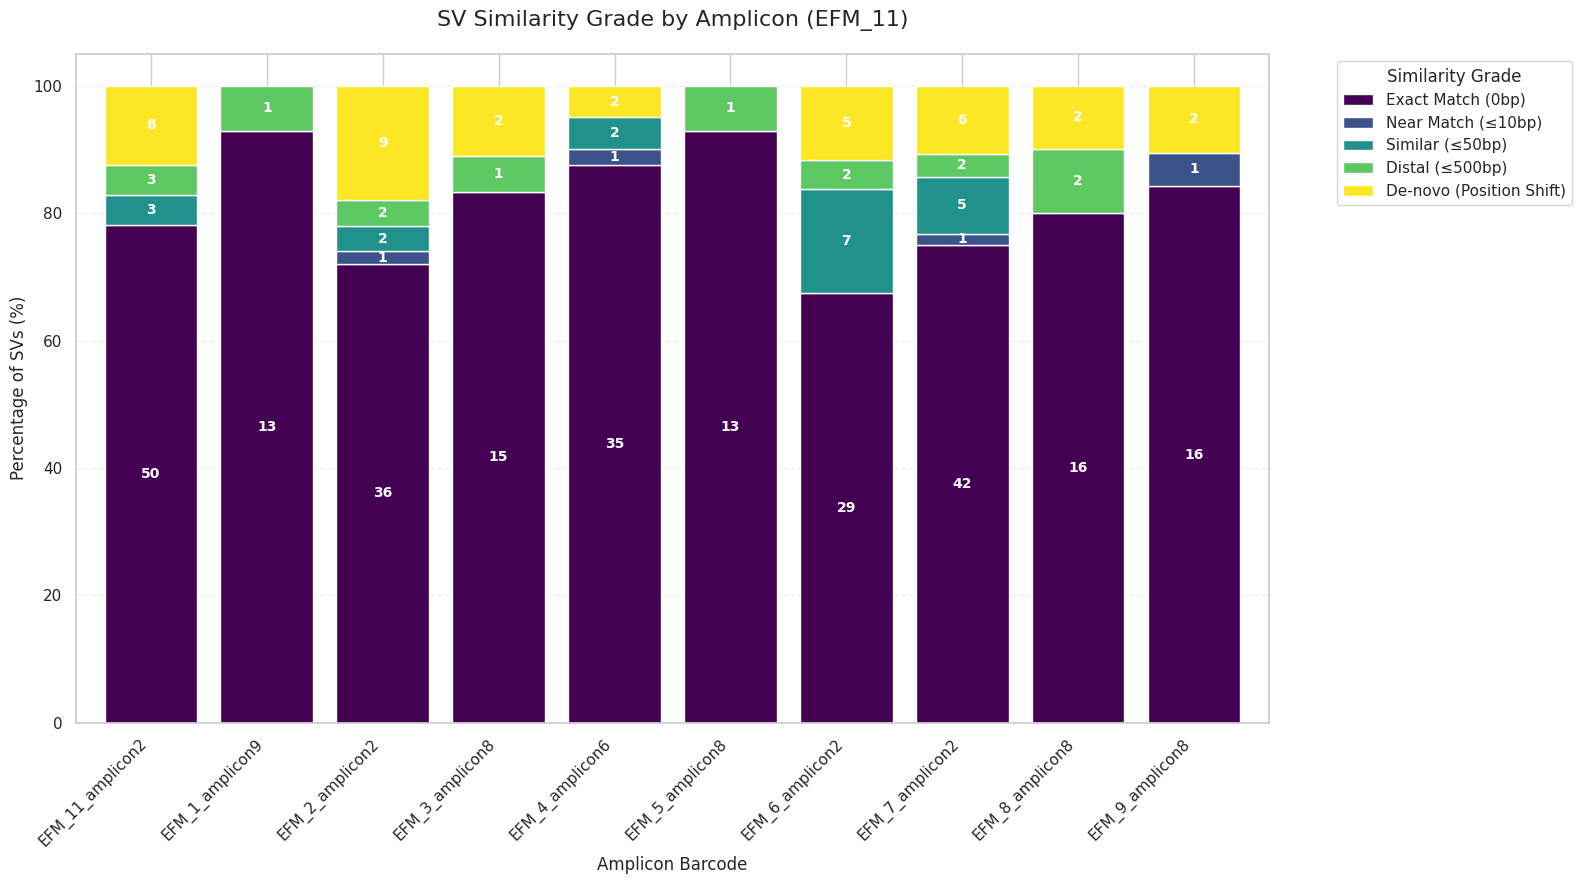

In [333]:
plot_df.head()
plot_df['sample_amp']=plot_df['sample_id']+'_'+plot_df['amplicon_number']

# 1. 분석 대상 샘플 필터링 (EFM_11)
target_df =plot_df.copy()

# 2. 분석 순서(Grade) 고정
order = ["Exact Match (0bp)", "Near Match (≤10bp)", "Similar (≤50bp)", "Distal (≤500bp)", "De-novo (Position Shift)"]

# 3. 개수(Count)와 비율(Percentage) 데이터 생성
pivot_df = target_df.groupby(['sample_amp', 'similarity_grade']).size().unstack(fill_value=0)
# 없는 등급은 0으로 채우고 순서 정렬
for col in order:
    if col not in pivot_df.columns:
        pivot_df[col] = 0
pivot_df = pivot_df[order]

# 비율 계산 (%)
pivot_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 4. 시각화
fig, ax = plt.subplots(figsize=(16, 9))
pivot_perc.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='white', width=0.8)

# 5. 막대 안에 실제 개수(Count) 써주기
for i, (name, row) in enumerate(pivot_perc.iterrows()):
    cumulative_height = 0
    for col in order:
        perc_val = row[col]
        count_val = pivot_df.loc[name, col]
        
        if count_val > 0:  # 데이터가 있는 경우에만 텍스트 표시
            # 텍스트 위치 계산 (각 누적 영역의 정중앙)
            pos_y = cumulative_height + (perc_val / 2)
            ax.text(i, pos_y, f'{int(count_val)}', 
                    ha='center', va='center', color='white', 
                    fontweight='bold', fontsize=10)
        
        cumulative_height += perc_val

# 6. 스타일링
plt.title('SV Similarity Grade by Amplicon (EFM_11)', fontsize=16, pad=20)
plt.xlabel('Amplicon Barcode', fontsize=12)
plt.ylabel('Percentage of SVs (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # 바코드 이름이 길면 45도 기울임
plt.legend(title='Similarity Grade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('sv_distribution_with_counts.png', dpi=300)
plt.show()

## structural retention analysis

1) interval 
2) Junction
3) structure transform

Observation: Parental ecDNA는 많은데 clone에서 ecDNA call이 감소
QC/Validation: 기술적 bias 여부 점검
Structural retention: interval/junction 기반으로 “진짜 소실 vs 형태전환” 판정
Architecture-aware clustering: oncogene CN + amplicon type 기반 clone grouping(heatmap)
Experiment plan: cluster별 대표 clone 선택 → therapy 투여 → resistance trajectory 비교
Next features: segment CN/complexity/SV(ERBB2 locus)/driver mutation 추가로 “mechanism-oriented stratification” 확장 제안

In [339]:
aa_cycles=pd.read_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260313_annotated_cycles_files.csv')
# (3626, 11)

aa_cycles=pd.merge(aa_cycles, aaSuite_gemline_ms[['aa_barcode','amplicon_index','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_index'])
print(aa_cycles.shape) #(3626, 14)


# aa_cycles_ECGI = aa_cycles[(aa_cycles['source_barcode']=='ECGI1')&(aa_cycles['sample_id']!='EG_21')]

# print(aa_cycles_ECGI.shape) #(2901, 14)

# aa_cycles_ECGI.head(2)


aa_cycles.head(2)

(5303, 14)


,file_name,aa_barcode,amplicon_index,cycle_index,cycle_barcode,Copy_count,Length,IsCyclicPath,CycleClass,Segments,Intervals,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,cycle1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,2.750858,154981,False,Invalid,"0+,1-,0+\n",15:20824661-20979641,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,cycle1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon1...,2.774022,265006,False,Linear,"0+,1-,0+\n",16:33268118-33533123,EFM19,EFM_5,Linear


In [338]:

def process_aa_cycles_to_cnv(df):
    """
    합쳐진 AA cycle 데이터를 정제하여 
    구간별 최종 Copy Number(CN)를 계산합니다.
    """
    # 1. Intervals 컬럼 분리 (예: "17:12624000-13920299")
    # 정규표현식을 사용해 chr, start, end를 추출합니다.
    coords = df['Intervals'].str.extract(r'(\d+):(\d+)-(\d+)')
    df['seqnames'] = 'chr' + coords[0]
    df['start'] = coords[1].astype(float)
    df['end'] = coords[2].astype(float)
    
    # 2. Copy_count를 수치형으로 변환
    df['copyNumber'] = pd.to_numeric(df['Copy_count'], errors='coerce')
    
    # 3. 중복 구간 통합 (가장 중요한 단계)
    # 동일한 앰플리콘 내에서 같은 좌표를 가진 조각들의 CN을 합산합니다.
    # AA 구조상 여러 Cycle이 같은 구간을 공유하면 실제 CN은 그 합입니다.
    final_cnv = df.groupby(
        ['aa_barcode', 'amplicon_index', 'seqnames', 'start', 'end']
    )['copyNumber'].sum().reset_index()
    
    # 컬럼명 정리 (김상현 선생님 코드 호환용)
    final_cnv = final_cnv.rename(columns={'amplicon_index': 'v'})
    
    return final_cnv

# --- 실행 예시 ---
# 박사님이 복사해주신 데이터를 df로 불러왔다고 가정할 때:
cnv_df = process_aa_cycles_to_cnv(aa_cycles)

# 확인용 출력
cnv_df.head()

,aa_barcode,amplicon_idx,seqnames,start,end,copyNumber
0,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,840697.0,1318199.0,2.756051
1,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,840697.0,2224739.0,4.277366
2,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,1004112.0,1004213.0,1.273404
3,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,1199945.0,2120873.0,2.177285
4,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,1912846.0,1913665.0,4.485499


In [158]:
aa_cycles=pd.merge(cnv_df, aaSuite_gemline_ms[['aa_barcode','amplicon_index','source_barcode','sample_id','amplicon_type']], how='left', on=['aa_barcode','amplicon_index'])


In [344]:
aa_cycles.head(2)

,aa_barcode,amplicon_index,seqnames,start,end,copyNumber,source_barcode,sample_id,amplicon_type
0,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,840697.0,1318199.0,2.756051,ECGI1,parental,ecDNA
1,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,amplicon1,chr1,840697.0,2224739.0,4.277366,ECGI1,parental,ecDNA


In [345]:
# aa_cycles.to_csv(f'{base_dir}/ECTRES-aaSuite_germline_ms-v1.3.8-GRCh37-minCN4.5-cnsizeMin50000-10X_20260320_processed_cycles_files.csv')

In [160]:
# OncogenesAmplified 컬럼의 쉼표로 구분된 유전자들을 explode
# 1. 먼저 쉼표(,)로 split → 리스트로 변환
df = aa_cycles_ECGI.copy()
df = df[df['CycleClass']!='Invalid']
# df = df[(df['CycleClass'].isin(['ecDNA-like','BFB-like']))&(df['sample_id']=='parental')]
df['Intervals_split'] = df['Intervals'].str.split(',')

# 2. explode를 통해 유전자별로 row 늘리기
df_exploded = df.explode('Intervals_split')

# 3. 양끝 공백 제거 및 빈 문자열 제거
df_exploded['Intervals_split'] = df_exploded['Intervals_split'].str.strip()
df_exploded = df_exploded[df_exploded['Intervals_split'] != '']

# 4. 컬럼명 정리
# df_exploded = df_exploded.rename(columns={'OncogenesAmplified_split': 'Oncogene'})
print(df_exploded.shape, df.shape)
# 결과 확인
df_exploded

NameError: name 'aa_cycles_ECGI' is not defined

In [161]:
df_exploded_all=df_exploded.copy()

In [162]:
df_exploded['IsCyclicPath'].unique()
df_exploded['CycleClass'].unique()
# array(['Invalid', 'Linear', 'Rearranged', 'BFB-like', 'BFB-like_Invalid',
#        'ecDNA-like'], dtype=object)

df_exploded.columns

df_exploded[['file_name', 'aa_barcode', 'amplicon_index', 'cycle_index',]]

KeyError: 'IsCyclicPath'

In [97]:
# 중복된 행 확인 (디버깅용)
duplicates = df_exploded[df_exploded.duplicated(subset=["Intervals_split", "sample_id"])]
print(f"중복된 행 개수: {len(duplicates)}")
# duplicates

중복된 행 개수: 12


In [98]:
interval_list=df_exploded[df_exploded['CycleClass']=='ecDNA-like']['Intervals_split'].unique().tolist()
interval_list

# df_exploded

['8:133740027-136798512',
 '8:133742514-136795218',
 '1:1199386-2120873',
 '1:1199945-2119874',
 '14:24195081-29617680',
 '16:70152088-70233382',
 '16:74396970-74430026',
 '1:153363250-153407852',
 '1:153408630-153418801',
 '1:160244494-160670989',
 '11:15088861-15089052',
 '1:160671040-161054710']

In [99]:
df_exploded['CycleClass'].unique()

array(['Rearranged', 'Linear', 'BFB-like', 'BFB-like_Invalid',
       'ecDNA-like'], dtype=object)

In [100]:
# df_exploded[(df_exploded['sample_id']=='parental')&(df_exploded['amplicon_type']=='ecDNA')]['amplicon_index'].unique()

# interval_list=df_exploded[(df_exploded['sample_id']=='parental')&(df_exploded['amplicon_type'].isin(['ecDNA','BFB-like']))]['Intervals_split'].unique().tolist()
interval_list=df_exploded[(df_exploded['amplicon_type'].isin(['ecDNA','BFB']))]['Intervals_split'].unique().tolist()
interval_list
len(interval_list)
# df_exploded

314

In [101]:
df_exploded.head(2)

,file_name,aa_barcode,amplicon_index,cycle_index,cycle_barcode,Copy_count,Length,IsCyclicPath,CycleClass,Segments,Intervals,source_barcode,sample_id,amplicon_type,Intervals_split
264,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388,amplicon11,cycle1,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,2.525651,562106,False,Rearranged,"0+,1+,3-,0+\n","5:56660725-56987192,5:56750400-56986037",ECGI1,EG_26,Linear,5:56660725-56987192
264,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388,amplicon11,cycle1,ECTRES-ECGI1-0001-TPX-A26-WGS-6JQ388_amplicon1...,2.525651,562106,False,Rearranged,"0+,1+,3-,0+\n","5:56660725-56987192,5:56750400-56986037",ECGI1,EG_26,Linear,5:56750400-56986037


In [102]:
df_exploded['CycleClass'].unique()


array(['Rearranged', 'Linear', 'BFB-like', 'BFB-like_Invalid',
       'ecDNA-like'], dtype=object)

In [103]:
color_map2 = {
    "ecDNA-like": "#d62728",                 # red
    "BFB-like": "#ff7f0e",                   # orange
    "BFB-like_Invalid": "#ff7f0e",                   # orange
    "Linear": "#1f77b4",  # blue
    "Rearranged": "#2ca02c",    # green
    "Invalid": "#7f7f7f"                # gray
}

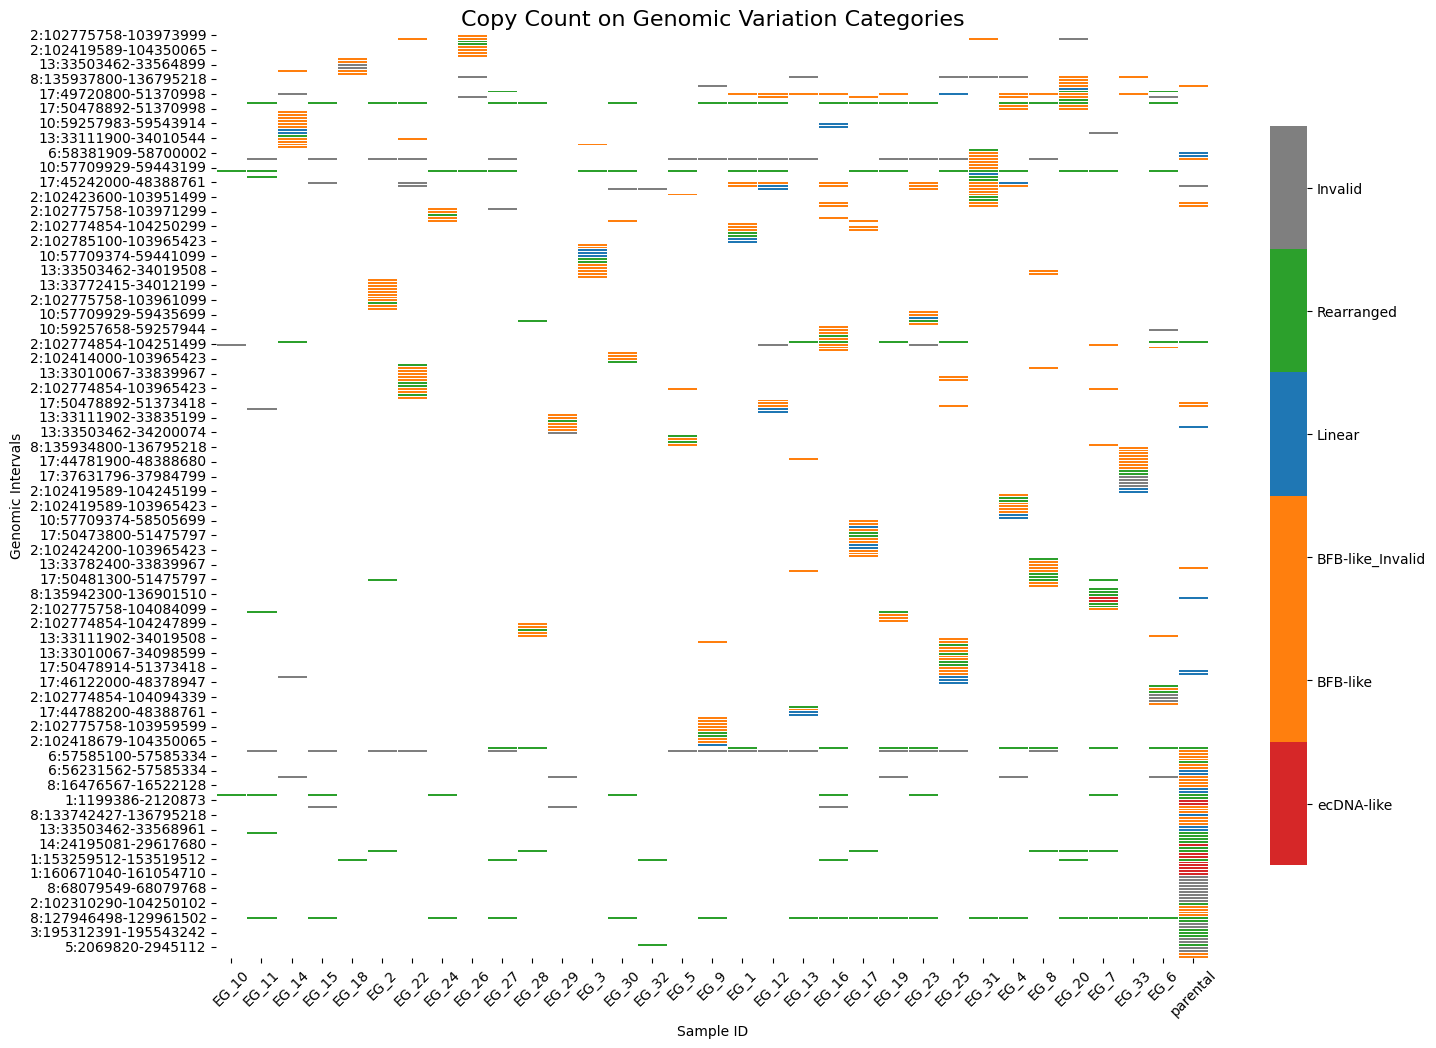

In [104]:
from matplotlib.colors import ListedColormap

# df_exploded = df_exploded_all.copy()

df_exploded = df_exploded_all[df_exploded_all['Intervals_split'].isin(interval_list)]

# 2. 피벗 테이블 생성 (기존 코드 유지)
cn_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="Copy_count",
    aggfunc='max'
).reindex(columns=ordered_samples)

cat_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="CycleClass",
    aggfunc=lambda x: x.iloc[0]
).reindex(columns=ordered_samples)


# 1. 'ecDNA-like'를 포함한 인터벌 필터링
# ecdna_intervals = cat_matrix.index[cat_matrix.isin(["ecDNA-like"]).any(axis=1)]

# 필터링된 데이터 생성
# cn_matrix_filtered = cn_matrix.loc[ecdna_intervals]
# cat_matrix_filtered = cat_matrix.loc[ecdna_intervals]
cn_matrix_filtered = cn_matrix.loc[interval_list]
cat_matrix_filtered = cat_matrix.loc[interval_list]

# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))  # 숫자가 잘 보이도록 사이즈를 넉넉히 조절

custom_cmap = ListedColormap(int_to_color)

# annot=cn_matrix_filtered: 실제 Copy Count 숫자를 셀에 표시
# fmt=".1f": 소수점 첫째자리까지 표시 (정수라면 "d"로 변경)
ax = sns.heatmap(
    cat_numeric, 
#     annot=cn_matrix_filtered, 
#     fmt=".1f", 
    cmap=custom_cmap, 
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

# 4. 컬러바 범례 설정 (오른쪽 바에 카테고리명 표시)
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

plt.title("Copy Count on Genomic Variation Categories", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

In [105]:
def parse_interval(s: str):
    """
    Returns: (chrom, start, end)
    Supports: chr17:123-456, 17:123-456, chr17_123_456, 17_123_456, chr17-123-456 ...
    """
    s = str(s)

    # 공통: chr 제거, 구분자 통일
    s2 = s.replace("CHR", "chr").replace("Chr", "chr")
    s2 = s2.replace("chr", "")
    s2 = re.sub(r"[,\s]", "", s2)  # comma/space 제거

    # 패턴들 시도
    patterns = [
        r"^(?P<chrom>[0-9XYM]+)[:](?P<start>\d+)[-](?P<end>\d+)$",     # 17:123-456
        r"^(?P<chrom>[0-9XYM]+)[_](?P<start>\d+)[_](?P<end>\d+)$",     # 17_123_456
        r"^(?P<chrom>[0-9XYM]+)[-](?P<start>\d+)[-](?P<end>\d+)$",     # 17-123-456
        r"^(?P<chrom>[0-9XYM]+)[:](?P<start>\d+)$",                    # 17:123 (end 없음)
        r"^(?P<chrom>[0-9XYM]+)[_](?P<start>\d+)$",                    # 17_123 (end 없음)
    ]

    chrom = start = end = np.nan
    for pat in patterns:
        m = re.match(pat, s2)
        if m:
            chrom = m.group("chrom")
            start = int(m.group("start"))
            end = int(m.group("end")) if "end" in m.groupdict() and m.group("end") else np.nan
            break

    return chrom, start, end

def chrom_to_order(chrom):
    """chr 자연 정렬: 1..22, X=23, Y=24, M/MT=25"""
    if pd.isna(chrom):
        return 1_000  # 파싱 실패한 것들은 맨 뒤
    c = str(chrom).upper()
    if c in ["X"]:
        return 23
    if c in ["Y"]:
        return 24
    if c in ["M", "MT"]:
        return 25
    try:
        return int(c)
    except:
        return 999

In [106]:
# Intervals_split에서 chr/start/end 추출
tmp = df_exploded[["Intervals_split"]].drop_duplicates().copy()
tmp[["chrom", "start", "end"]] = tmp["Intervals_split"].apply(lambda x: pd.Series(parse_interval(x)))
tmp["chrom_order"] = tmp["chrom"].apply(chrom_to_order)

# 정렬된 interval 순서
interval_order = (
    tmp.sort_values(["chrom_order", "start", "end"], na_position="last")["Intervals_split"]
    .tolist()
)

# (선택) 파싱 실패한 interval 확인
bad = tmp[tmp["chrom"].isna() | tmp["start"].isna()]
# display(bad)  # 주피터에서 확인용
# bad

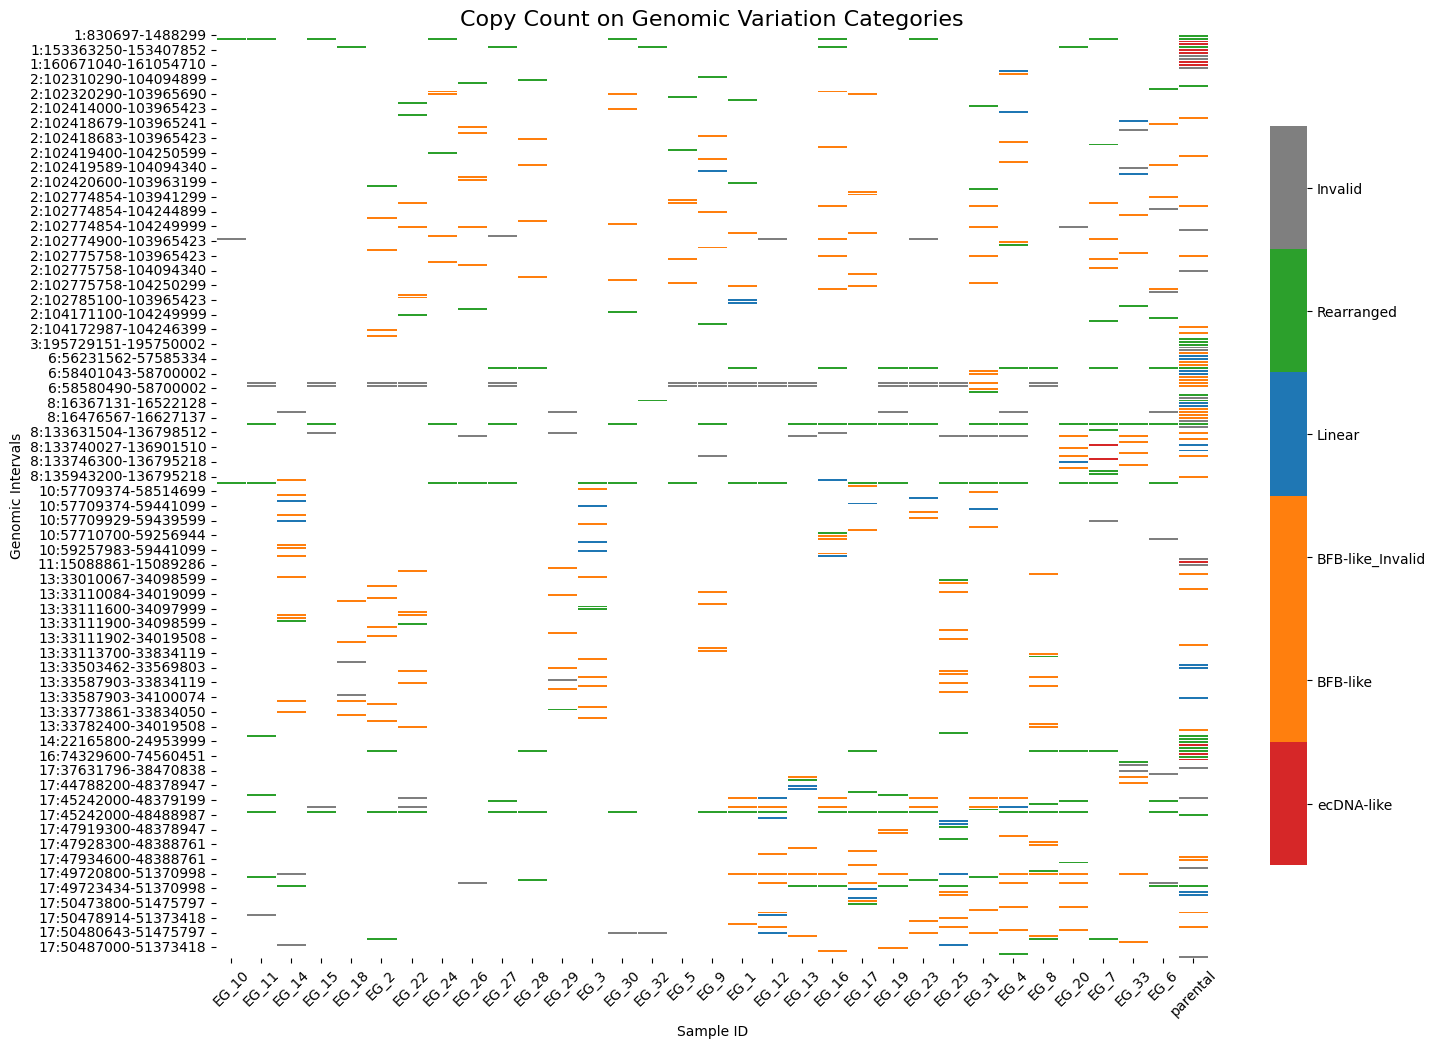

In [107]:
from matplotlib.colors import ListedColormap

df_exploded = df_exploded_all.copy()

df_exploded = df_exploded_all[df_exploded_all['Intervals_split'].isin(interval_list)]

# pivot 결과 cn_matrix, cat_matrix가 이미 만들어져 있다고 가정
cn_matrix_sorted = cn_matrix.reindex(index=interval_order)
cat_matrix_sorted = cat_matrix.reindex(index=interval_order)

# heatmap에 넣을 row subset이 interval_list라면, 그 subset도 genomic order로 정렬:
interval_list_sorted = [x for x in interval_order if x in set(interval_list)]

cn_matrix_filtered = cn_matrix_sorted.loc[interval_list_sorted]
cat_matrix_filtered = cat_matrix_sorted.loc[interval_list_sorted]

# heatmap에 넣을 row subset이 interval_list라면, 그 subset도 genomic order로 정렬:
interval_list_sorted = [x for x in interval_order if x in set(interval_list)]

cn_matrix_filtered = cn_matrix_sorted.loc[interval_list_sorted]
cat_matrix_filtered = cat_matrix_sorted.loc[interval_list_sorted]



# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))  # 숫자가 잘 보이도록 사이즈를 넉넉히 조절

custom_cmap = ListedColormap(int_to_color)

# annot=cn_matrix_filtered: 실제 Copy Count 숫자를 셀에 표시
# fmt=".1f": 소수점 첫째자리까지 표시 (정수라면 "d"로 변경)
ax = sns.heatmap(
    cat_numeric, 
#     annot=cn_matrix_filtered, 
#     fmt=".1f", 
    cmap=custom_cmap, 
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

# 4. 컬러바 범례 설정 (오른쪽 바에 카테고리명 표시)
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

plt.title("Copy Count on Genomic Variation Categories", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

In [108]:
# interval_list로 필터된 df_exploded를 이미 만들었다고 가정
# df_exploded = df_exploded_all[df_exploded_all['Intervals_split'].isin(interval_list)]

cn_mat = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="Copy_count",
    aggfunc="max"
)

# 원하는 interval만/원하는 순서로
cn_mat = cn_mat.loc[interval_list]

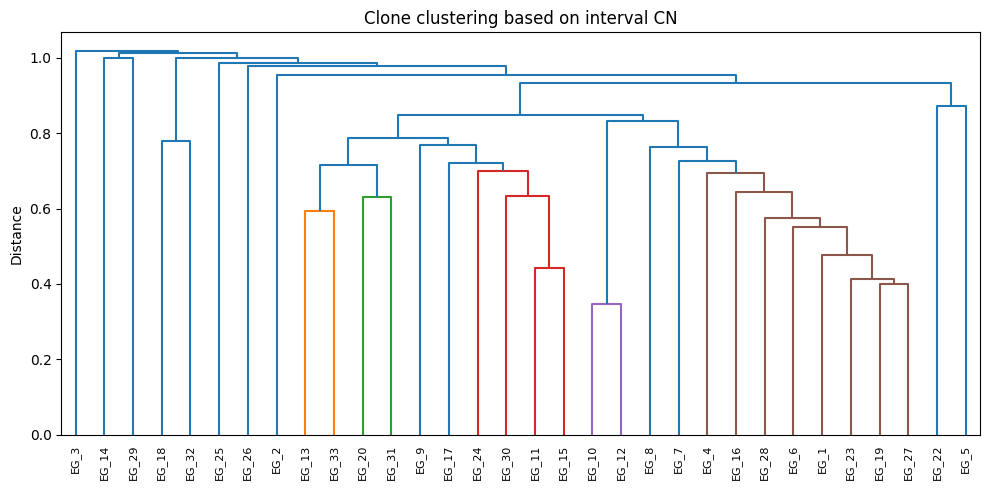

In [109]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt



X = cn_mat.copy()

# 결측은 0으로 (없으면 0 copy로 취급)
X = X.fillna(0)

# parental 제외
cols = X.columns.tolist()
has_parental = "parental" in cols
clone_cols = [c for c in cols if c != "parental"]

X_clone = X[clone_cols].T  # rows=sample, cols=interval feature

# 추천: correlation (패턴 유사성)
dist = pdist(X_clone, metric="correlation")
Z = linkage(dist, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=X_clone.index, leaf_rotation=90)
plt.title("Clone clustering based on interval CN")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

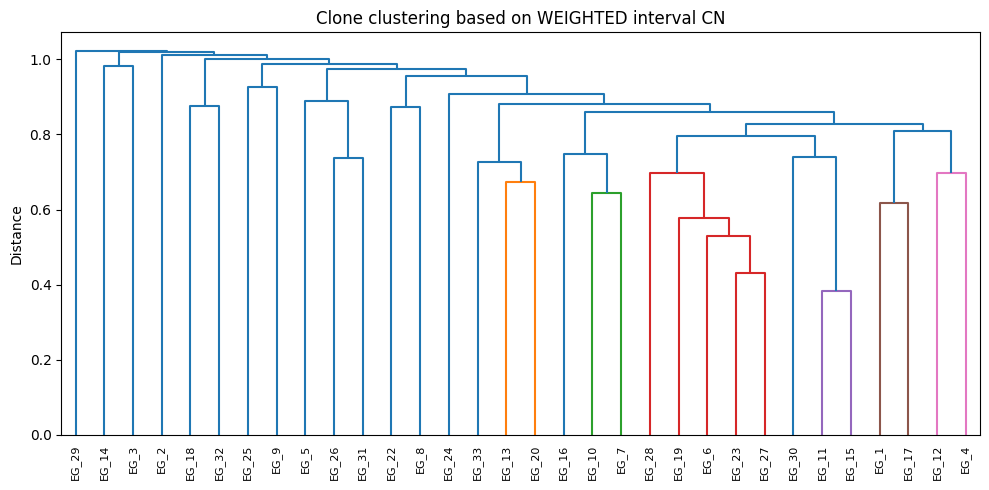

In [110]:
class_weight = {
    "ecDNA-like": 5,
    "BFB-like": 4,
    "BFB-like_Invalid": 3,
    "Linear": 2,
    "Rearranged": 1,
    "Invalid": 0   # Invalid는 아예 영향 없게(원하면 1로)
}
cn = cn_mat.fillna(0)

cat = cat_matrix.copy()

w_mat = cat.applymap(lambda x: class_weight.get(x, 1))  # 모르는 class는 weight=1 기본
cn_weighted = cn * w_mat


from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

X = cn_weighted.fillna(0)

has_parental = "parental" in X.columns
clone_cols = [c for c in X.columns if c != "parental"]

X_clone = X[clone_cols].T  # rows=sample, cols=interval feature

# correlation(패턴 중심) 추천
dist = pdist(X_clone, metric="correlation")
Z = linkage(dist, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=X_clone.index, leaf_rotation=90)
plt.title("Clone clustering based on WEIGHTED interval CN")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [111]:
k = 5
labels = fcluster(Z, t=k, criterion="maxclust")
cluster_df_interval = pd.DataFrame({
    "sample_id": X_clone.index,
    "cluster_group": labels
}).sort_values(["cluster_group", "sample_id"])

cluster_df_interval

,sample_id,cluster_group
5,EG_14,1
21,EG_3,1
9,EG_18,2
24,EG_32,2
0,EG_1,3
1,EG_10,3
2,EG_11,3
3,EG_12,3
4,EG_13,3
6,EG_15,3


In [112]:
ordered_samples = cluster_df_interval["sample_id"].tolist()

if has_parental:
    ordered_samples = ordered_samples + ["parental"]

In [113]:
# 기존처럼 다시 만드셔도 되고, 이미 만든 cn_mat/cat_matrix를 재사용해도 됩니다.
cn_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="Copy_count",
    aggfunc="max"
).loc[interval_list, ordered_samples]

cat_matrix = df_exploded.pivot_table(
    index="Intervals_split",
    columns="sample_id",
    values="CycleClass",
    aggfunc=lambda x: x.iloc[0]
).loc[interval_list, ordered_samples]

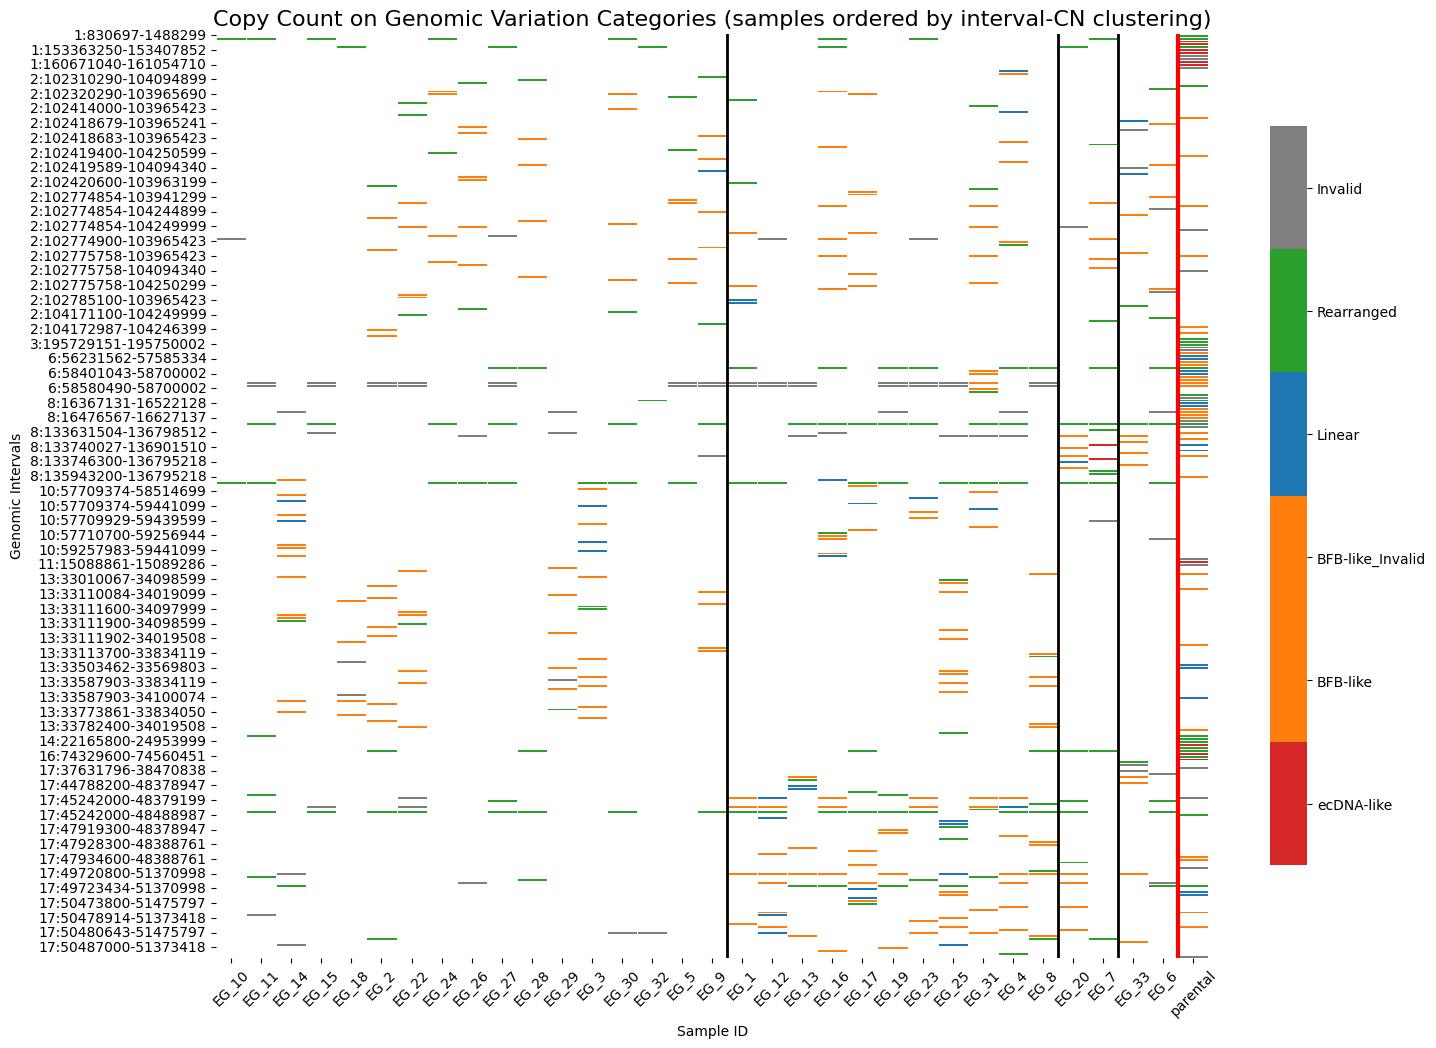

In [114]:
# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))
custom_cmap = ListedColormap(int_to_color)

ax = sns.heatmap(
    cat_numeric,
    # annot=cn_matrix_filtered,   # 원하면 다시 켜세요
    # fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# 4. 컬러바 범례 설정 (오른쪽 바에 카테고리명 표시)
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

# ✅ cluster boundary 선
for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# ✅ parental 맨 오른쪽 강조선 (있을 때만)
if "parental" in ordered_samples:
    parental_pos = ordered_samples.index("parental")
    ax.axvline(parental_pos, color="red", linewidth=3)

plt.title("Copy Count on Genomic Variation Categories (samples ordered by interval-CN clustering)", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

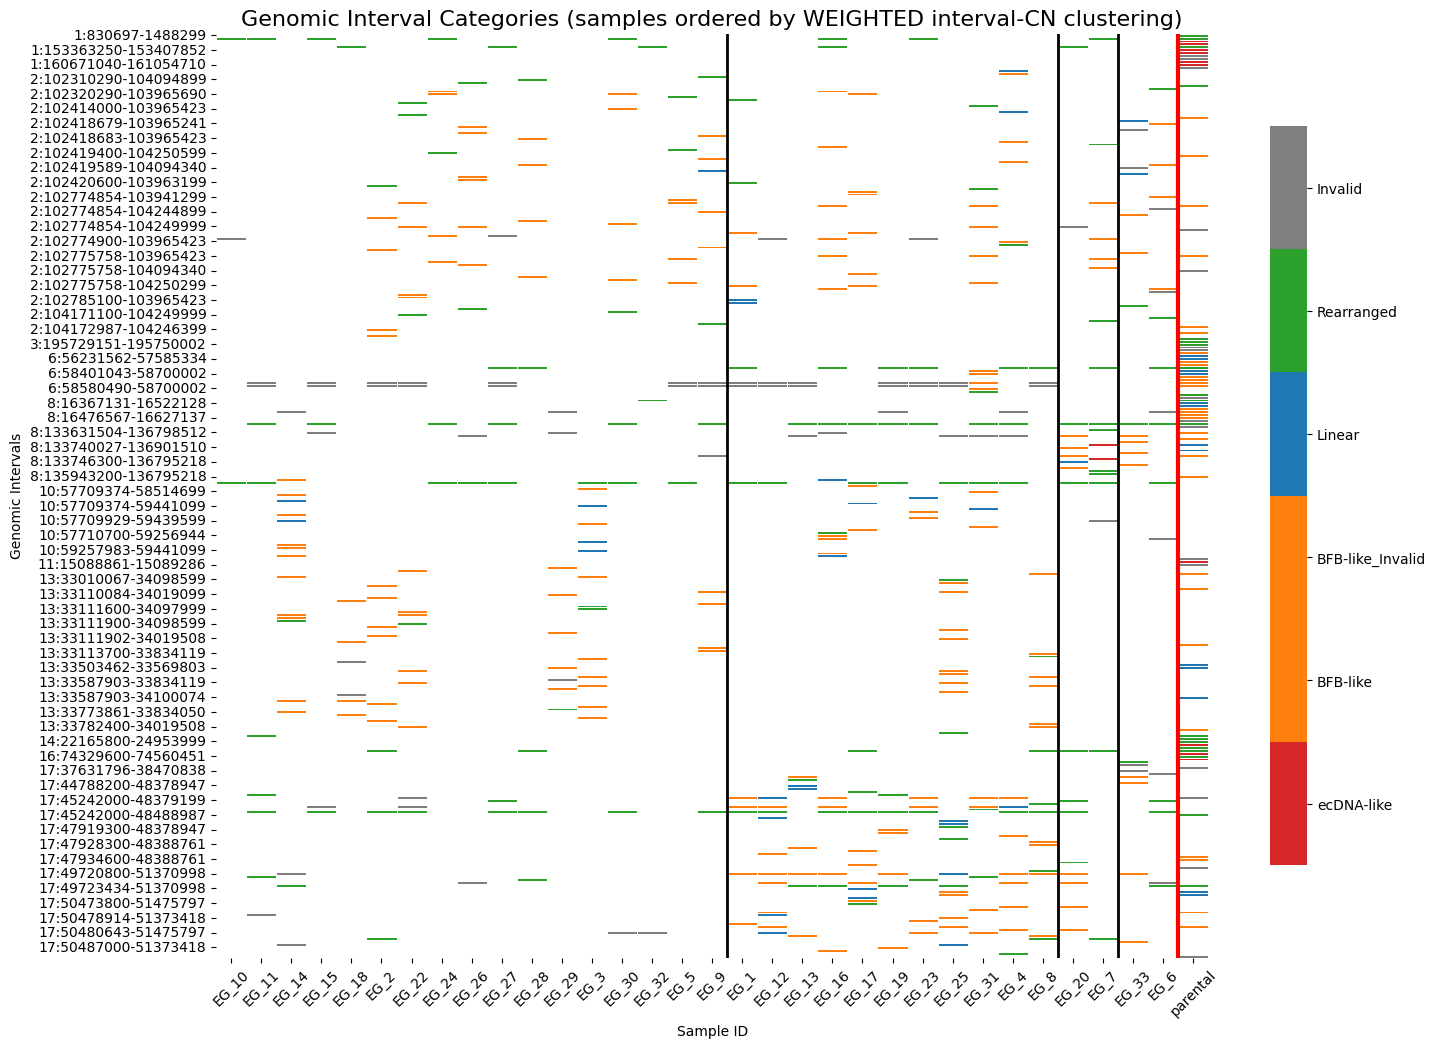

In [115]:
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

# 2. 카테고리(문자열)를 숫자로 매핑 (컬러맵 적용용)
category_labels = list(color_map2.keys())
category_to_int = {label: i for i, label in enumerate(category_labels)}
int_to_color = [color_map2[label] for label in category_labels]

# 히트맵 배경용 숫자 행렬
cat_numeric = cat_matrix_filtered.replace(category_to_int)

# 3. 히트맵 그리기
plt.figure(figsize=(16, 12))
custom_cmap = ListedColormap(int_to_color)

ax = sns.heatmap(
    cat_numeric,
    # ✅ 숫자 표시를 원하면 아래 둘 중 하나 선택
    # annot=cn_matrix_filtered,    # raw Copy_count 표시
    # annot=cn_weighted,           # weighted Copy_count 표시
    # fmt=".1f",
    cmap=custom_cmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)

# 4. 컬러바 범례 설정
colorbar = ax.collections[0].colorbar
num_labels = len(category_labels)
r = colorbar.vmax - colorbar.vmin
colorbar.set_ticks([colorbar.vmin + r / num_labels * (i + 0.5) for i in range(num_labels)])
colorbar.set_ticklabels(category_labels)

# ✅ cluster boundary 선
for b in boundaries:
    ax.axvline(b, color="black", linewidth=2)

# ✅ parental 맨 오른쪽 강조선
if "parental" in ordered_samples:
    parental_pos = ordered_samples.index("parental")
    ax.axvline(parental_pos, color="red", linewidth=3)

plt.title("Genomic Interval Categories (samples ordered by WEIGHTED interval-CN clustering)", fontsize=16)
plt.ylabel("Genomic Intervals")
plt.xlabel("Sample ID")
plt.xticks(rotation=45)
plt.show()

In [168]:
path='/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_feature_similarity/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/10X/ecDNA/aaSuite_feature_similarity/ECTRES-EFM19-0001/run_similarity'
similarity=pd.read_csv(f'{path}/ECTRES-EFM19-0001_feature_similarity_scores.tsv',sep='\t')
print(similarity.shape)

similarity.head()



(98, 19)


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen
0,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,3.0,3,3,489323,489323,489323
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2...,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,481213,481213,481213
2,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2...,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8...,1.000,100.0,0.000000e+00,1.0,1.00,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1,1,61494,61494,61494
3,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323
4,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2...,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2...,0.875,100.0,5.056982e-07,1.0,0.75,1.0,1.0,1.0,0.666667,1.0,0.666667,2.0,2,3,489323,489323,489323
